In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:

# ==========================================
# 1. General Libraries
# ==========================================
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# ==========================================
# 2. Visualization
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 3. Audio Processing
# ==========================================
import librosa
import librosa.display
import soundfile as sf
import torchaudio

from IPython.display import Audio, display

# ==========================================
# 4. Deep Learning (PyTorch)
# ==========================================
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# ==========================================
# 5. Pretrained Audio Transformer (AST)
# ==========================================
from transformers import (
    AutoFeatureExtractor,
    ASTForAudioClassification
)

# ==========================================
# 6. Evaluation Metrics
# ==========================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ==========================================
# 7. Progress Bar
# ==========================================
from tqdm.auto import tqdm

# ==========================================
# 8. Basic Configuration
# ==========================================
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)
print("PyTorch Version:", torch.__version__)
print("All imports completed!")


Device: cuda
PyTorch Version: 2.11.0+cu128
All imports completed!


In [2]:

from pathlib import Path
import pandas as pd
import soundfile as sf
from IPython.display import FileLink, display

# Paths
ROOT = Path("/kaggle/input/datasets/chrisfilo/urbansound8k")
CSV_PATH = ROOT / "UrbanSound8K.csv"
OUTPUT = Path("/kaggle/working/dataset_overview.txt")

# Load metadata
df = pd.read_csv(CSV_PATH)

report = []

def add(title, content):
    report.append(f"\n{'='*60}\n{title}\n{'='*60}")
    report.append(str(content))

# 1. Basic information
add("DATASET SHAPE", df.shape)
add("COLUMN NAMES", df.columns.tolist())
add("COLUMN DATA TYPES", df.dtypes.to_string())

# 2. First 15 records
add("FIRST 15 ROWS", df.head(15).to_string(index=False))

# 3. Class distribution
add("CLASS DISTRIBUTION", df["class"].value_counts().to_string())

# 4. Fold distribution
add("FOLD DISTRIBUTION", df["fold"].value_counts().sort_index().to_string())

# 5. Class distribution across folds
add("CLASS-WISE FOLD DISTRIBUTION",
    pd.crosstab(df["fold"], df["class"]).to_string())

# 6. Missing values
add("MISSING VALUES", df.isnull().sum().to_string())

# 7. Missing audio files
missing = [
    row["slice_file_name"]
    for _, row in df.iterrows()
    if not (ROOT / f"fold{row['fold']}" / row["slice_file_name"]).is_file()
]
add("MISSING AUDIO FILES", f"Count: {len(missing)}\nExamples: {missing[:10]}")

# 8. One audio example per class
audio_info = []

for _, row in df.groupby("class").first().reset_index().iterrows():
    path = ROOT / f"fold{row['fold']}" / row["slice_file_name"]

    try:
        info = sf.info(str(path))
        audio_info.append(
            f"Class: {row['class']}\n"
            f"File: {row['slice_file_name']}\n"
            f"Sample Rate: {info.samplerate} Hz\n"
            f"Duration: {info.duration:.3f} seconds\n"
            f"Channels: {info.channels}\n"
            f"Subtype: {info.subtype}\n"
        )
    except Exception as e:
        audio_info.append(f"{path.name}: {e}")

add("SAMPLE AUDIO INFORMATION", "\n".join(audio_info))

# Save report
OUTPUT.write_text("\n".join(report), encoding="utf-8")

print("Dataset overview generated successfully!")
print("Total records:", len(df))
print("Total classes:", df["class"].nunique())

display(FileLink(str(OUTPUT)))


Dataset overview generated successfully!
Total records: 8732
Total classes: 10


/kaggle/working/dataset_overview.txt

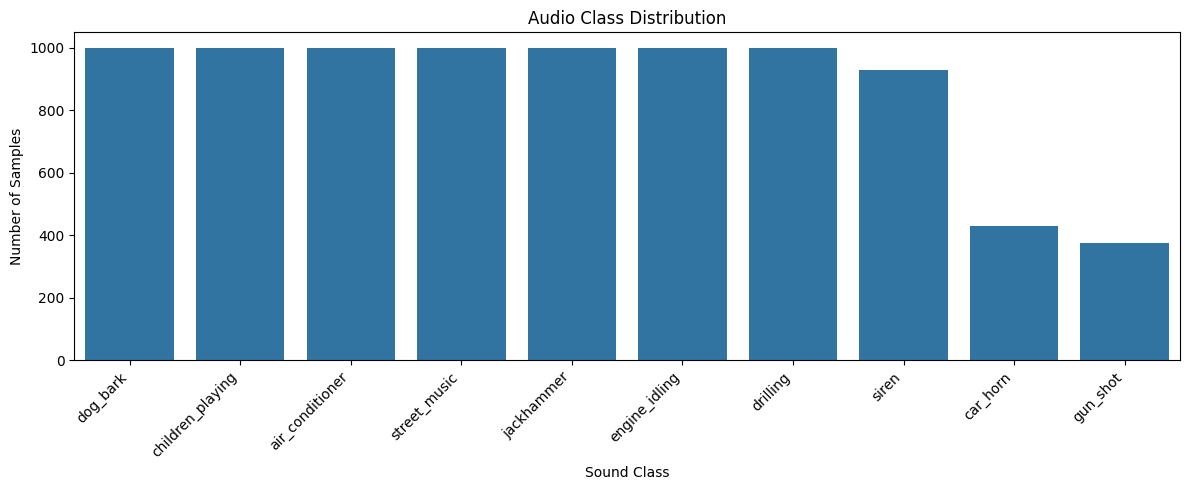

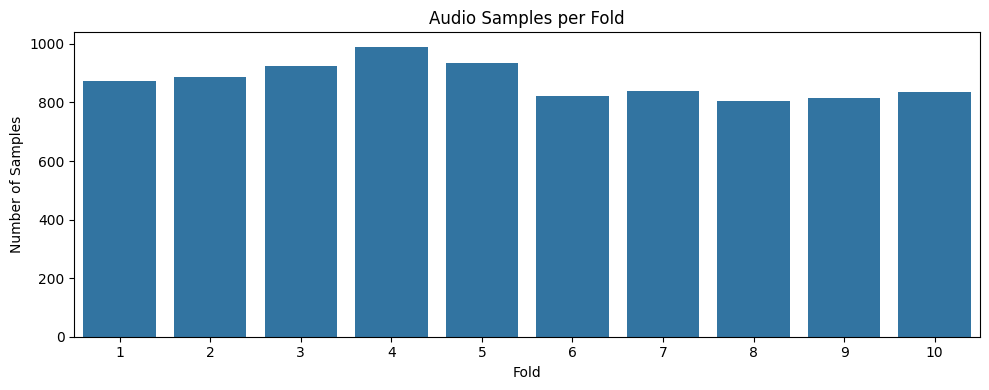

Class: dog_bark
Filename: 100032-3-0-0.wav
Sample Rate: 44100
Duration: 0.318 seconds


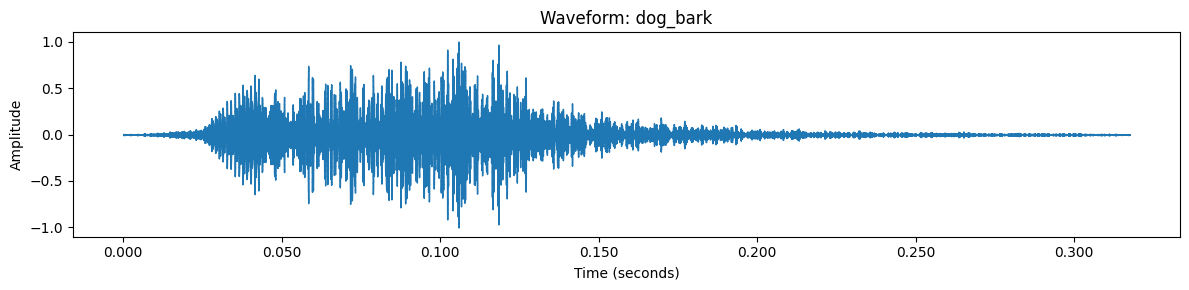

In [3]:

# ==========================================
# Exploratory Data Analysis (EDA)
# ==========================================

ROOT = Path("/kaggle/input/datasets/chrisfilo/urbansound8k")
df = pd.read_csv(ROOT / "UrbanSound8K.csv")

# 1. Class Distribution
plt.figure(figsize=(12, 5))
sns.countplot(
    data=df,
    x="class",
    order=df["class"].value_counts().index
)
plt.title("Audio Class Distribution")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Sound Class")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

# 2. Fold Distribution
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="fold", order=range(1, 11))
plt.title("Audio Samples per Fold")
plt.xlabel("Fold")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

# 3. Load and Listen to a Sample Audio
sample = df.iloc[0]
audio_path = ROOT / f"fold{sample['fold']}" / sample["slice_file_name"]

y, sr = librosa.load(audio_path, sr=None, mono=True)

print("Class:", sample["class"])
print("Filename:", sample["slice_file_name"])
print("Sample Rate:", sr)
print("Duration:", round(len(y) / sr, 3), "seconds")

display(Audio(y, rate=sr))

# 4. Visualize Waveform
plt.figure(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Waveform: {sample['class']}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


  0%|          | 0/8732 [00:00<?, ?it/s]

=== SAMPLE RATE DISTRIBUTION ===
sample_rate
8000        12
11024        7
11025       39
16000       45
22050       44
24000       82
32000        4
44100     5370
48000     2502
96000      610
192000      17
Name: count, dtype: int64

=== CHANNEL DISTRIBUTION ===
channels
1     739
2    7993
Name: count, dtype: int64

=== AUDIO DURATION STATISTICS ===
count    8732.000000
mean        3.607522
std         0.974394
min         0.050000
25%         4.000000
50%         4.000000
75%         4.000000
max         4.036647
Name: duration, dtype: float64

=== AUDIO FORMAT DISTRIBUTION ===
subtype
PCM_16       5758
PCM_24       2753
FLOAT         169
PCM_U8         43
MS_ADPCM        8
IMA_ADPCM       1
Name: count, dtype: int64

=== SHORT AUDIO COUNT ===
Less than 4 seconds: 1398
Approximately 4 seconds: 7334


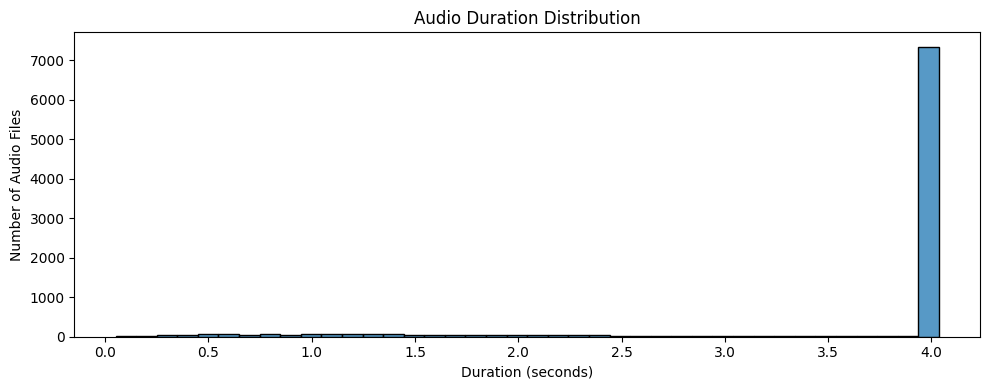

In [4]:

# ==========================================
# Audio Properties Analysis
# ==========================================

audio_stats = []

for row in tqdm(df.itertuples(index=False), total=len(df)):
    path = ROOT / f"fold{row.fold}" / row.slice_file_name
    info = sf.info(str(path))

    audio_stats.append({
        "sample_rate": info.samplerate,
        "duration": info.duration,
        "channels": info.channels,
        "subtype": info.subtype
    })

stats_df = pd.DataFrame(audio_stats)

print("=== SAMPLE RATE DISTRIBUTION ===")
print(stats_df["sample_rate"].value_counts().sort_index())

print("\n=== CHANNEL DISTRIBUTION ===")
print(stats_df["channels"].value_counts().sort_index())

print("\n=== AUDIO DURATION STATISTICS ===")
print(stats_df["duration"].describe())

print("\n=== AUDIO FORMAT DISTRIBUTION ===")
print(stats_df["subtype"].value_counts())

print("\n=== SHORT AUDIO COUNT ===")
print("Less than 4 seconds:",
      (stats_df["duration"] < 3.99).sum())

print("Approximately 4 seconds:",
      (stats_df["duration"] >= 3.99).sum())

# Duration Visualization
plt.figure(figsize=(10, 4))
sns.histplot(stats_df["duration"], bins=40)

plt.title("Audio Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Audio Files")
plt.tight_layout()
plt.show()


========== DATASET ==========
Total samples: 8732
Target sample rate: 16000
Target duration: 4 seconds
Target waveform length: 64000

========== SAMPLE INFORMATION ==========
File: 100032-3-0-0.wav
Class: dog_bark
Fold: 5
Original sample rate: 44100
Original channels: 2
Original duration: 0.318

========== AFTER PREPROCESSING ==========
Sample rate: 16000
Channels: 1
Duration: 4.0
Waveform shape: (64000,)
Waveform dtype: float32
AST feature shape: torch.Size([1024, 128])
Label: 3

Preprocessing verification passed!


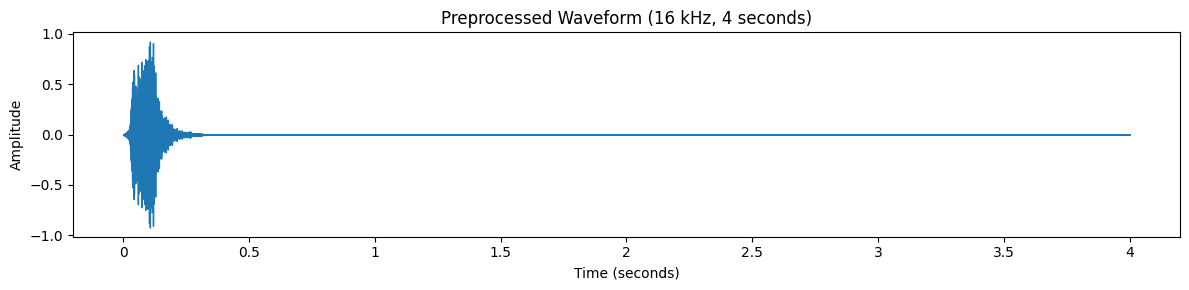

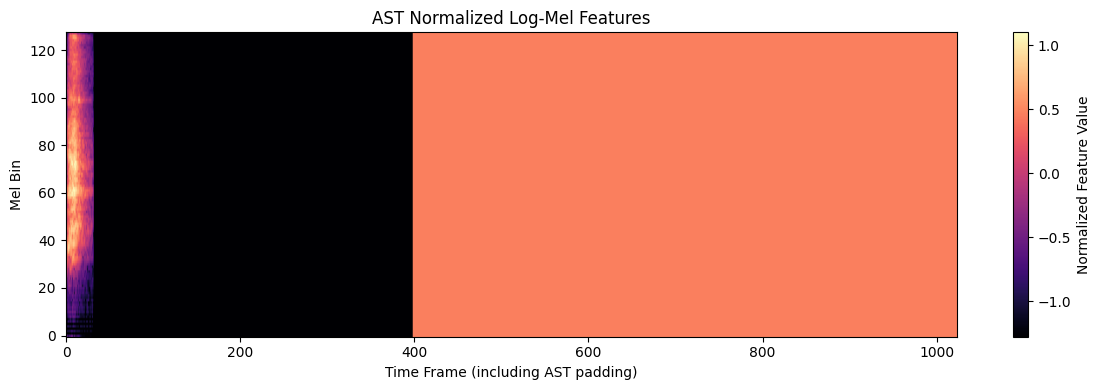

In [5]:

# ============================================================
# UrbanSound8K Preprocessing Pipeline for AST
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import torch
from torch.utils.data import Dataset
from transformers import ASTFeatureExtractor
import matplotlib.pyplot as plt

# 1. Configuration
ROOT = Path("/kaggle/input/datasets/chrisfilo/urbansound8k")
SAMPLE_RATE = 16000
DURATION = 4
TARGET_SAMPLES = SAMPLE_RATE * DURATION
N_MELS = 128

df = pd.read_csv(ROOT / "UrbanSound8K.csv")

# 2. AST Feature Extractor
# Uses standard AudioSet AST preprocessing settings.
# Later verify against the selected pretrained checkpoint.
feature_extractor = ASTFeatureExtractor(
    sampling_rate=SAMPLE_RATE,
    num_mel_bins=N_MELS,
    max_length=1024,
    do_normalize=True
)

# 3. Waveform Preprocessing
def preprocess_waveform(file_path):

    # Decode audio, convert to mono and resample to 16 kHz
    waveform, sr = librosa.load(
        str(file_path),
        sr=SAMPLE_RATE,
        mono=True
    )

    # Pad short audio with zeros or crop long audio to 4s
    waveform = librosa.util.fix_length(
        waveform,
        size=TARGET_SAMPLES
    )

    return waveform.astype(np.float32)


# 4. PyTorch Dataset
class UrbanSound8KDataset(Dataset):

    def __init__(self, metadata, root, folds=None):
        self.root = Path(root)

        if folds is not None:
            metadata = metadata[metadata["fold"].isin(folds)]

        self.metadata = metadata.reset_index(drop=True)

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):

        row = self.metadata.iloc[idx]

        audio_path = (
            self.root
            / f"fold{int(row['fold'])}"
            / row["slice_file_name"]
        )

        # Waveform preprocessing
        waveform = preprocess_waveform(audio_path)

        # Log-Mel extraction + AST-specific normalization
        features = feature_extractor(
            waveform,
            sampling_rate=SAMPLE_RATE,
            return_tensors="pt"
        )["input_values"].squeeze(0)

        label = torch.tensor(
            int(row["classID"]),
            dtype=torch.long
        )

        return {
            "input_values": features,
            "labels": label
        }


# 5. Initialize Dataset (preserve all official folds)
dataset = UrbanSound8KDataset(df, ROOT)

print("========== DATASET ==========")
print("Total samples:", len(dataset))
print("Target sample rate:", SAMPLE_RATE)
print("Target duration:", DURATION, "seconds")
print("Target waveform length:", TARGET_SAMPLES)


# 6. Test Preprocessing on One Sample
row = df.iloc[0]
audio_path = ROOT / f"fold{int(row['fold'])}" / row["slice_file_name"]

original_info = sf.info(str(audio_path))
processed_waveform = preprocess_waveform(audio_path)
sample = dataset[0]

print("\n========== SAMPLE INFORMATION ==========")
print("File:", row["slice_file_name"])
print("Class:", row["class"])
print("Fold:", row["fold"])
print("Original sample rate:", original_info.samplerate)
print("Original channels:", original_info.channels)
print("Original duration:", round(original_info.duration, 3))

print("\n========== AFTER PREPROCESSING ==========")
print("Sample rate:", SAMPLE_RATE)
print("Channels: 1")
print("Duration:", len(processed_waveform) / SAMPLE_RATE)
print("Waveform shape:", processed_waveform.shape)
print("Waveform dtype:", processed_waveform.dtype)
print("AST feature shape:", sample["input_values"].shape)
print("Label:", sample["labels"].item())

assert len(processed_waveform) == TARGET_SAMPLES
assert sample["input_values"].shape == (1024, 128)
assert torch.isfinite(sample["input_values"]).all()

print("\nPreprocessing verification passed!")


# 7. Visualize Processed Waveform
plt.figure(figsize=(12, 3))
librosa.display.waveshow(
    processed_waveform,
    sr=SAMPLE_RATE
)
plt.title("Preprocessed Waveform (16 kHz, 4 seconds)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


# 8. Visualize AST Input Features
plt.figure(figsize=(12, 4))
plt.imshow(
    sample["input_values"].numpy().T,
    aspect="auto",
    origin="lower",
    cmap="magma"
)
plt.title("AST Normalized Log-Mel Features")
plt.xlabel("Time Frame (including AST padding)")
plt.ylabel("Mel Bin")
plt.colorbar(label="Normalized Feature Value")
plt.tight_layout()
plt.show()


========== CONFIGURATION ==========
Device: cuda
PyTorch: 2.11.0+cu128
Smoke Test: True
Sample Rate: 16000
Maximum Duration: 4.0
GPU: Tesla T4

========== DATASET ==========
Total samples: 8732
Total classes: 10

Class Mapping:
0: air_conditioner
1: car_horn
2: children_playing
3: dog_bark
4: drilling
5: engine_idling
6: gun_shot
7: jackhammer
8: siren
9: street_music


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]


========== AST FEATURE EXTRACTOR ==========
Sampling Rate: 16000
Mel Bins: 128
Max Frames: 1024
Normalization: True

========== PREPROCESSING VERIFICATION ==========

Class: car_horn
File: 87275-1-2-0.wav
Original Duration (metadata): 0.055s
Processed Duration: 0.050s
Waveform Shape: (800,)
AST Feature Shape: (1024, 128)

Class: dog_bark
File: 100032-3-0-0.wav
Original Duration (metadata): 0.318s
Processed Duration: 0.318s
Waveform Shape: (5081,)
AST Feature Shape: (1024, 128)

Class: children_playing
File: 100263-2-0-117.wav
Original Duration (metadata): 4.000s
Processed Duration: 4.000s
Waveform Shape: (64000,)
AST Feature Shape: (1024, 128)


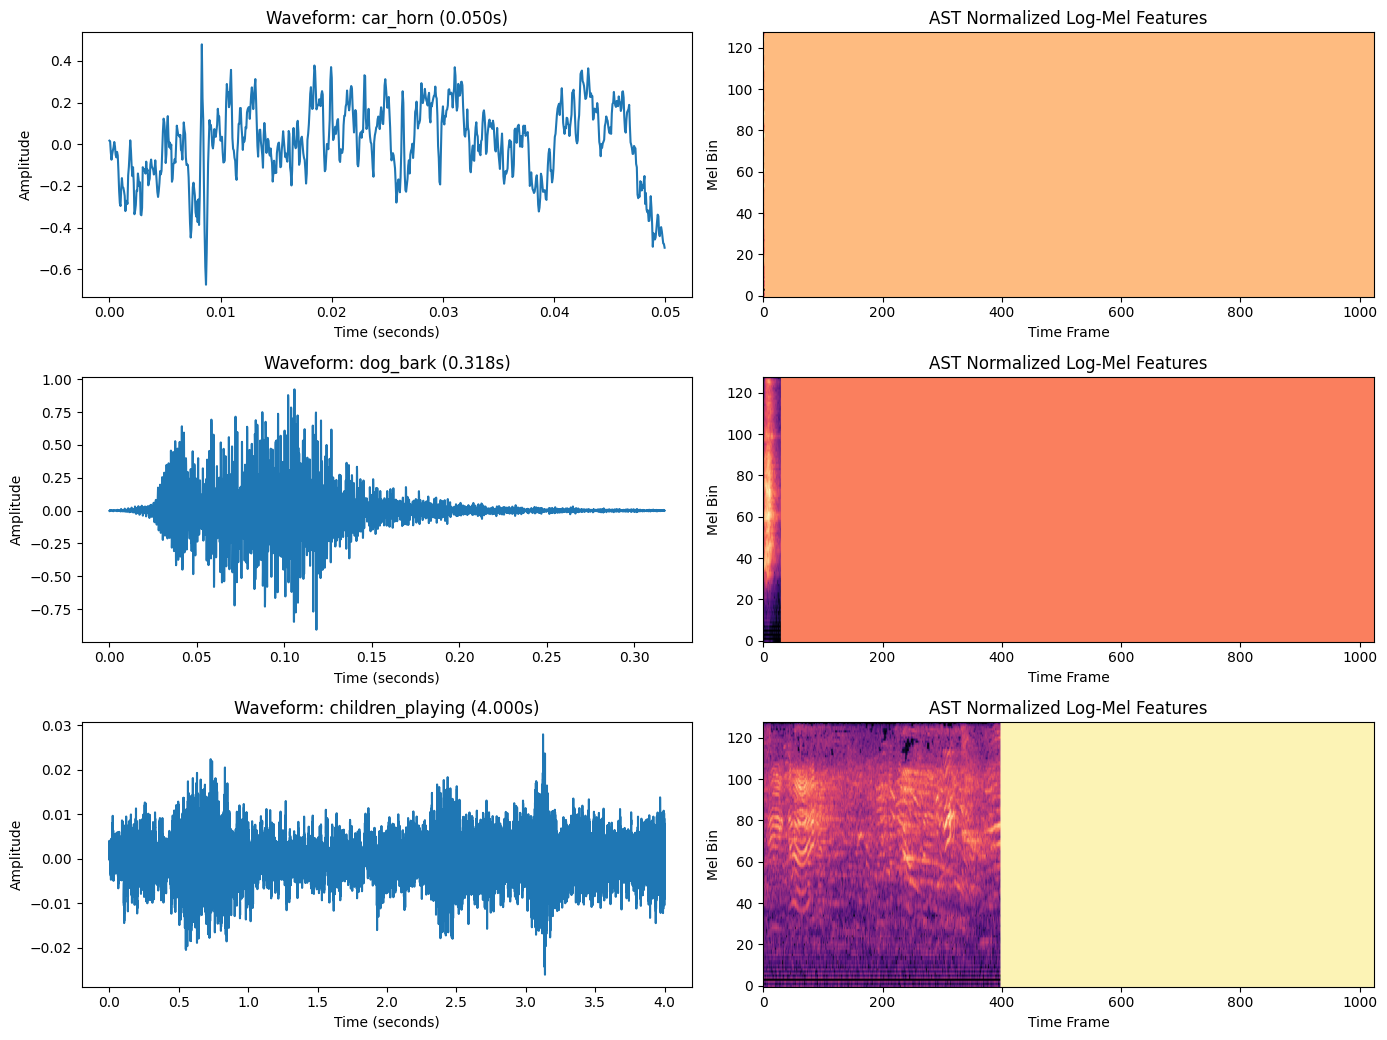


Preprocessing verification passed!

========== LEAKAGE VERIFICATION ==========
Train folds: [1, 2, 4, 5, 6, 7, 8, 9]
Validation folds: [3]
Test folds: [10]

Train-Val fsID overlap: 0
Train-Test fsID overlap: 0
Val-Test fsID overlap: 0

Source IDs appearing in multiple official folds:
fsID
77751     2
106905    2
132016    2
176638    2
180937    2

Source-level leakage verification passed!

========== DATASET SPLIT ==========
Train samples: 6970
Validation samples: 925
Test samples: 837
Dataset split verification passed!

========== DATALOADER VERIFICATION ==========
Input Shape: (2, 1024, 128)
Label Shape: (2,)
Labels: [2, 3]

DataLoader verification passed!

========== LOADING AST ==========


config.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `527`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

...

Training:   0%|          | 0/2 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch 1/1
Train | Loss: 2.8521 | Accuracy: 0.0000 | Macro-F1: 0.0000
Valid | Loss: 2.2190 | Accuracy: 0.5000 | Macro-F1: 0.0667

========== TRAINING COMPLETED ==========


,epoch,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1
0,1,2.852051,0.0,0.0,2.218994,0.5,0.066667


Smoke test passed. Metrics from only a few batches are not meaningful performance estimates.
Held-out test fold was NOT evaluated.


In [6]:

# ============================================================
# PROJECT 8: UrbanSound8K - AST Pipeline
# Corrected Preprocessing + DataLoader + Training Smoke Test
# ============================================================

import random
from pathlib import Path
from itertools import islice

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import torch

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from transformers import (
    AutoFeatureExtractor,
    ASTForAudioClassification
)

from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm


# ============================================================
# 1. CONFIGURATION
# ============================================================

ROOT = Path("/kaggle/input/datasets/chrisfilo/urbansound8k")
MODEL_NAME = "MIT/ast-finetuned-audioset-10-10-0.4593"

SEED = 42
SAMPLE_RATE = 16000
MAX_DURATION = 4.0
MAX_SAMPLES = int(SAMPLE_RATE * MAX_DURATION)

SMOKE_TEST = True

EPOCHS = 1 if SMOKE_TEST else 10
BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 2
NUM_WORKERS = 0

MAX_TRAIN_BATCHES = 2 if SMOKE_TEST else None
MAX_VAL_BATCHES = 2 if SMOKE_TEST else None

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("========== CONFIGURATION ==========")
print("Device:", DEVICE)
print("PyTorch:", torch.__version__)
print("Smoke Test:", SMOKE_TEST)
print("Sample Rate:", SAMPLE_RATE)
print("Maximum Duration:", MAX_DURATION)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available. Training will be skipped.")


# ============================================================
# 2. LOAD METADATA AND CLASS MAPPING
# ============================================================

assert ROOT.is_dir(), f"Dataset not found: {ROOT}"

df = pd.read_csv(ROOT / "UrbanSound8K.csv")

label_table = (
    df[["classID", "class"]]
    .drop_duplicates()
    .sort_values("classID")
)

# Fixed: use positional tuples instead of accessing 'class'
id2label = {
    int(class_id): str(class_name)
    for class_id, class_name in label_table.itertuples(
        index=False, name=None
    )
}

label2id = {
    class_name: class_id
    for class_id, class_name in id2label.items()
}

assert len(id2label) == 10
assert set(id2label.keys()) == set(range(10))

print("\n========== DATASET ==========")
print("Total samples:", len(df))
print("Total classes:", len(id2label))

print("\nClass Mapping:")
for class_id, class_name in id2label.items():
    print(f"{class_id}: {class_name}")


# ============================================================
# 3. LOAD AST FEATURE EXTRACTOR
# ============================================================

feature_extractor = AutoFeatureExtractor.from_pretrained(
    MODEL_NAME
)

assert feature_extractor.sampling_rate == SAMPLE_RATE
assert feature_extractor.num_mel_bins == 128

print("\n========== AST FEATURE EXTRACTOR ==========")
print("Sampling Rate:", feature_extractor.sampling_rate)
print("Mel Bins:", feature_extractor.num_mel_bins)
print("Max Frames:", feature_extractor.max_length)
print("Normalization:", feature_extractor.do_normalize)


# ============================================================
# 4. CORRECTED WAVEFORM PREPROCESSING
# ============================================================

def preprocess_waveform(audio_path):
    """
    1. Decode WAV
    2. Convert stereo to mono
    3. Resample to 16 kHz
    4. Crop to maximum 4 seconds

    No waveform zero-padding.
    AST Feature Extractor handles spectrogram padding.
    """

    waveform, sr = librosa.load(
        str(audio_path),
        sr=SAMPLE_RATE,
        mono=True,
        duration=MAX_DURATION
    )

    waveform = waveform[:MAX_SAMPLES]

    return waveform.astype(np.float32)


def extract_ast_features(waveform):
    """
    Checkpoint-specific feature processing:
    - Log-Mel extraction
    - Padding/truncation
    - Normalization
    """

    result = feature_extractor(
        waveform,
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt"
    )

    return result["input_values"].squeeze(0)


# ============================================================
# 5. VERIFY SHORT AND FULL-LENGTH AUDIO
# ============================================================

df_check = df.copy()
df_check["duration"] = df_check["end"] - df_check["start"]

sample_indices = [
    df_check["duration"].idxmin(),
    (df_check["duration"] - 0.318).abs().idxmin(),
    (df_check["duration"] - 4.0).abs().idxmin()
]

sample_indices = list(dict.fromkeys(sample_indices))

fig, axes = plt.subplots(
    len(sample_indices),
    2,
    figsize=(14, 3.5 * len(sample_indices)),
    squeeze=False
)

print("\n========== PREPROCESSING VERIFICATION ==========")

for i, idx in enumerate(sample_indices):

    row = df_check.loc[idx]

    audio_path = (
        ROOT
        / f"fold{int(row['fold'])}"
        / row["slice_file_name"]
    )

    waveform = preprocess_waveform(audio_path)
    features = extract_ast_features(waveform)

    duration = len(waveform) / SAMPLE_RATE

    assert 0 < len(waveform) <= MAX_SAMPLES

    assert features.shape == (
        feature_extractor.max_length,
        feature_extractor.num_mel_bins
    )

    assert torch.isfinite(features).all()

    print(f"\nClass: {row['class']}")
    print(f"File: {row['slice_file_name']}")
    print(f"Original Duration (metadata): {row['duration']:.3f}s")
    print(f"Processed Duration: {duration:.3f}s")
    print("Waveform Shape:", waveform.shape)
    print("AST Feature Shape:", tuple(features.shape))

    # Waveform
    time_axis = np.arange(len(waveform)) / SAMPLE_RATE

    axes[i, 0].plot(time_axis, waveform)
    axes[i, 0].set_title(
        f"Waveform: {row['class']} ({duration:.3f}s)"
    )
    axes[i, 0].set_xlabel("Time (seconds)")
    axes[i, 0].set_ylabel("Amplitude")

    # AST features
    axes[i, 1].imshow(
        features.numpy().T,
        origin="lower",
        aspect="auto",
        cmap="magma"
    )
    axes[i, 1].set_title("AST Normalized Log-Mel Features")
    axes[i, 1].set_xlabel("Time Frame")
    axes[i, 1].set_ylabel("Mel Bin")

plt.tight_layout()
plt.show()

print("\nPreprocessing verification passed!")


# ============================================================
# 6. CORRECTED OFFICIAL FOLD SPLIT
# ============================================================

# Important:
# These folds avoid cross-split fsID overlaps in this dataset.
# They are for development, NOT final 10-fold CV.

TRAIN_FOLDS = [1, 2, 4, 5, 6, 7, 8, 9]
VAL_FOLDS = [3]
TEST_FOLDS = [10]

# Ensure no fold is assigned to multiple splits
assert set(TRAIN_FOLDS).isdisjoint(VAL_FOLDS)
assert set(TRAIN_FOLDS).isdisjoint(TEST_FOLDS)
assert set(VAL_FOLDS).isdisjoint(TEST_FOLDS)

assert (
    set(TRAIN_FOLDS)
    | set(VAL_FOLDS)
    | set(TEST_FOLDS)
) == set(range(1, 11))

# Source recording IDs for each split
train_ids = set(
    df.loc[df["fold"].isin(TRAIN_FOLDS), "fsID"]
)

val_ids = set(
    df.loc[df["fold"].isin(VAL_FOLDS), "fsID"]
)

test_ids = set(
    df.loc[df["fold"].isin(TEST_FOLDS), "fsID"]
)

# Diagnostic checks
train_val_overlap = train_ids & val_ids
train_test_overlap = train_ids & test_ids
val_test_overlap = val_ids & test_ids

print("\n========== LEAKAGE VERIFICATION ==========")

print("Train folds:", TRAIN_FOLDS)
print("Validation folds:", VAL_FOLDS)
print("Test folds:", TEST_FOLDS)

print("\nTrain-Val fsID overlap:", len(train_val_overlap))
print("Train-Test fsID overlap:", len(train_test_overlap))
print("Val-Test fsID overlap:", len(val_test_overlap))

# Show the overlap exceptions across official folds
cross_fold_sources = (
    df.groupby("fsID")["fold"]
    .nunique()
)

cross_fold_sources = cross_fold_sources[
    cross_fold_sources > 1
]

print("\nSource IDs appearing in multiple official folds:")
print(cross_fold_sources.to_string())

# Validate actual source isolation
assert not train_val_overlap, (
    f"Train-Val leakage: {sorted(train_val_overlap)}"
)

assert not train_test_overlap, (
    f"Train-Test leakage: {sorted(train_test_overlap)}"
)

assert not val_test_overlap, (
    f"Val-Test leakage: {sorted(val_test_overlap)}"
)

print("\nSource-level leakage verification passed!")


# ============================================================
# 7. PYTORCH DATASET
# ============================================================

class UrbanSound8KASTDataset(Dataset):

    def __init__(self, metadata, root, folds):

        self.root = Path(root)

        selected = metadata[
            metadata["fold"].isin(folds)
        ].reset_index(drop=True)

        self.samples = []

        for filename, fold, class_id in selected[
            ["slice_file_name", "fold", "classID"]
        ].itertuples(index=False, name=None):

            audio_path = (
                self.root
                / f"fold{int(fold)}"
                / filename
            )

            self.samples.append(
                (audio_path, int(class_id))
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        audio_path, label = self.samples[idx]

        waveform = preprocess_waveform(audio_path)
        features = extract_ast_features(waveform)

        return {
            "input_values": features,
            "labels": torch.tensor(label, dtype=torch.long)
        }


# ============================================================
# 8. CREATE DATASETS
# ============================================================

train_dataset = UrbanSound8KASTDataset(
    df, ROOT, TRAIN_FOLDS
)

val_dataset = UrbanSound8KASTDataset(
    df, ROOT, VAL_FOLDS
)

test_dataset = UrbanSound8KASTDataset(
    df, ROOT, TEST_FOLDS
)

print("\n========== DATASET SPLIT ==========")
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

assert (
    len(train_dataset)
    + len(val_dataset)
    + len(test_dataset)
) == len(df)

print("Dataset split verification passed!")


# ============================================================
# 9. DATALOADERS
# ============================================================

loader_config = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": USE_AMP
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
    **loader_config
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_config
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_config
)

# Verify one batch
batch = next(iter(train_loader))

print("\n========== DATALOADER VERIFICATION ==========")

print("Input Shape:", tuple(batch["input_values"].shape))
print("Label Shape:", tuple(batch["labels"].shape))
print("Labels:", batch["labels"].tolist())

expected_shape = (
    BATCH_SIZE,
    feature_extractor.max_length,
    feature_extractor.num_mel_bins
)

assert tuple(batch["input_values"].shape) == expected_shape
assert torch.isfinite(batch["input_values"]).all()

print("\nDataLoader verification passed!")


# ============================================================
# 10. LOAD PRETRAINED AST
# ============================================================

if DEVICE.type != "cuda":

    print("\n========== GPU REQUIRED ==========")
    print("Preprocessing: PASSED")
    print("Data splitting: PASSED")
    print("DataLoader: PASSED")
    print("AST training: SKIPPED")
    print("\nEnable a Kaggle GPU and rerun the cell.")

else:

    print("\n========== LOADING AST ==========")

    model = ASTForAudioClassification.from_pretrained(
        MODEL_NAME,
        num_labels=10,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    model.config.problem_type = "single_label_classification"
    model = model.to(DEVICE)

    # Freeze backbone during smoke test only
    FREEZE_BACKBONE = SMOKE_TEST

    if FREEZE_BACKBONE:
        for p in model.audio_spectrogram_transformer.parameters():
            p.requires_grad = False

    trainable_params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    print("Model: AST")
    print("Number of classes:", model.config.num_labels)
    print("Backbone frozen:", FREEZE_BACKBONE)
    print("Trainable parameters:", f"{trainable_params:,}")

    # ========================================================
    # 11. OPTIMIZER AND SCHEDULER
    # ========================================================

    backbone_params = [
        p for p in model.audio_spectrogram_transformer.parameters()
        if p.requires_grad
    ]

    head_params = [
        p for p in model.classifier.parameters()
        if p.requires_grad
    ]

    parameter_groups = []

    if backbone_params:
        parameter_groups.append({
            "params": backbone_params,
            "lr": 1e-5
        })

    parameter_groups.append({
        "params": head_params,
        "lr": 1e-4
    })

    optimizer = AdamW(
        parameter_groups,
        weight_decay=0.01
    )

    scheduler = CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP
    )

    # ========================================================
    # 12. TRAINING AND VALIDATION
    # ========================================================

    def run_epoch(loader, training=True, max_batches=None):

        if training:
            model.train()

            if FREEZE_BACKBONE:
                model.audio_spectrogram_transformer.eval()
        else:
            model.eval()

        total_loss = 0.0
        total_samples = 0

        all_labels = []
        all_predictions = []

        n_batches = len(loader)

        if max_batches is not None:
            n_batches = min(n_batches, max_batches)

        if training:
            optimizer.zero_grad(set_to_none=True)

        iterator = tqdm(
            islice(loader, n_batches),
            total=n_batches,
            desc="Training" if training else "Validation",
            leave=False
        )

        for step, batch in enumerate(iterator):

            inputs = batch["input_values"].to(
                DEVICE,
                non_blocking=True
            )

            labels = batch["labels"].to(
                DEVICE,
                non_blocking=True
            )

            with torch.set_grad_enabled(training):

                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16,
                    enabled=USE_AMP
                ):

                    outputs = model(
                        input_values=inputs,
                        labels=labels
                    )

                    loss = outputs.loss
                    logits = outputs.logits

                if training:

                    # Correct handling of incomplete
                    # gradient accumulation groups
                    group_start = (
                        step // GRAD_ACCUM_STEPS
                    ) * GRAD_ACCUM_STEPS

                    group_size = min(
                        GRAD_ACCUM_STEPS,
                        n_batches - group_start
                    )

                    scaler.scale(
                        loss / group_size
                    ).backward()

                    should_step = (
                        (step + 1) % GRAD_ACCUM_STEPS == 0
                        or step + 1 == n_batches
                    )

                    if should_step:

                        scaler.unscale_(optimizer)

                        torch.nn.utils.clip_grad_norm_(
                            model.parameters(),
                            max_norm=1.0
                        )

                        scaler.step(optimizer)
                        scaler.update()

                        optimizer.zero_grad(set_to_none=True)

            batch_size = labels.size(0)

            total_loss += loss.item() * batch_size
            total_samples += batch_size

            predictions = logits.argmax(dim=1)

            all_labels.extend(
                labels.detach().cpu().tolist()
            )

            all_predictions.extend(
                predictions.detach().cpu().tolist()
            )

        avg_loss = total_loss / total_samples

        accuracy = accuracy_score(
            all_labels,
            all_predictions
        )

        macro_f1 = f1_score(
            all_labels,
            all_predictions,
            labels=list(range(10)),
            average="macro",
            zero_division=0
        )

        return avg_loss, accuracy, macro_f1

    # ========================================================
    # 13. TRAINING LOOP
    # ========================================================

    print("\n========== TRAINING ==========")

    print(
        "Mode:",
        "SMOKE TEST" if SMOKE_TEST else "FULL TRAINING"
    )

    print("Epochs:", EPOCHS)

    history = []

    for epoch in range(EPOCHS):

        train_loss, train_acc, train_f1 = run_epoch(
            train_loader,
            training=True,
            max_batches=MAX_TRAIN_BATCHES
        )

        val_loss, val_acc, val_f1 = run_epoch(
            val_loader,
            training=False,
            max_batches=MAX_VAL_BATCHES
        )

        scheduler.step()

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "train_macro_f1": train_f1,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "val_macro_f1": val_f1
        })

        print(f"\nEpoch {epoch + 1}/{EPOCHS}")

        print(
            f"Train | Loss: {train_loss:.4f} | "
            f"Accuracy: {train_acc:.4f} | "
            f"Macro-F1: {train_f1:.4f}"
        )

        print(
            f"Valid | Loss: {val_loss:.4f} | "
            f"Accuracy: {val_acc:.4f} | "
            f"Macro-F1: {val_f1:.4f}"
        )

    print("\n========== TRAINING COMPLETED ==========")

    display(pd.DataFrame(history))

    if SMOKE_TEST:
        print(
            "Smoke test passed. Metrics from only a few "
            "batches are not meaningful performance estimates."
        )

    print("Held-out test fold was NOT evaluated.")


## dont run this cell

========== CONFIGURATION ==========
Total Audio: 8732
Sample Rate: 16000
Max Duration: 4.0
AST Feature Shape: (1024, 128)
Device: CPU compatible

========== FULL DATASET VERIFICATION ==========


Verifying all audio:   0%|          | 0/8732 [00:00<?, ?it/s]


========== VERIFICATION RESULTS ==========
Total Audio: 8732
Successful: 8732
Failed: 0
Short Audio (<3.99s): 1398
Minimum Duration: 0.05
Maximum Duration: 4.0

All audio preprocessing checks PASSED!

========== SELECTED AUDIO ==========
Audio A: dog_bark
Audio B: children_playing

========== AUGMENTATION VERIFICATION ==========
Original Shape: (1024, 128)
Shifted Shape: (1024, 128)
Noisy Shape: (1024, 128)
Mixup Shape: (1024, 128)
SpecAugment Shape: (1024, 128)

Mixup lambda: 0.0
dog_bark target weight: 0.0
children_playing target weight: 1.0

All augmentation checks PASSED!


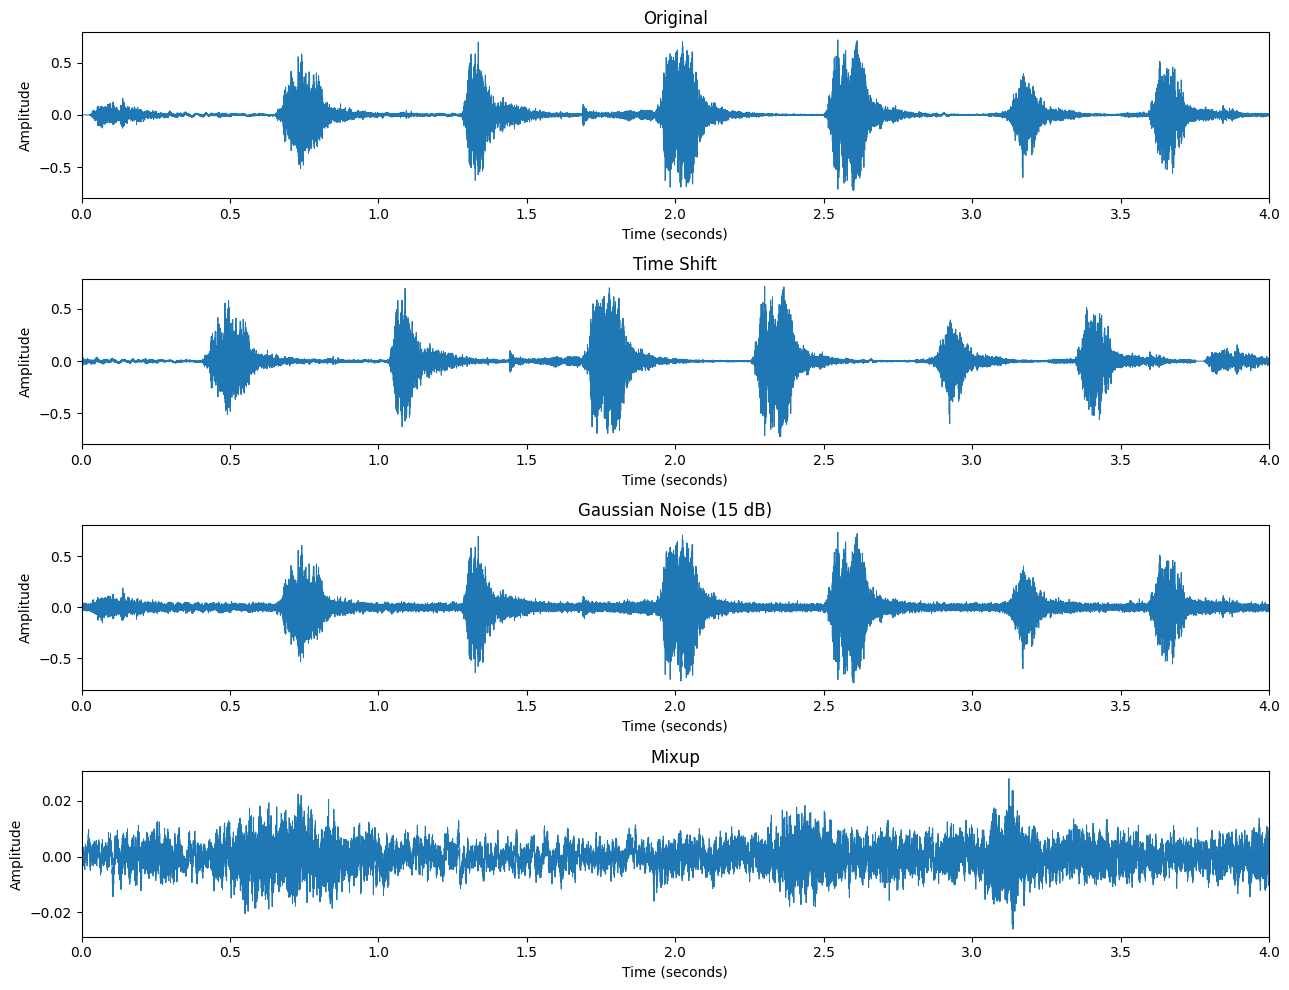

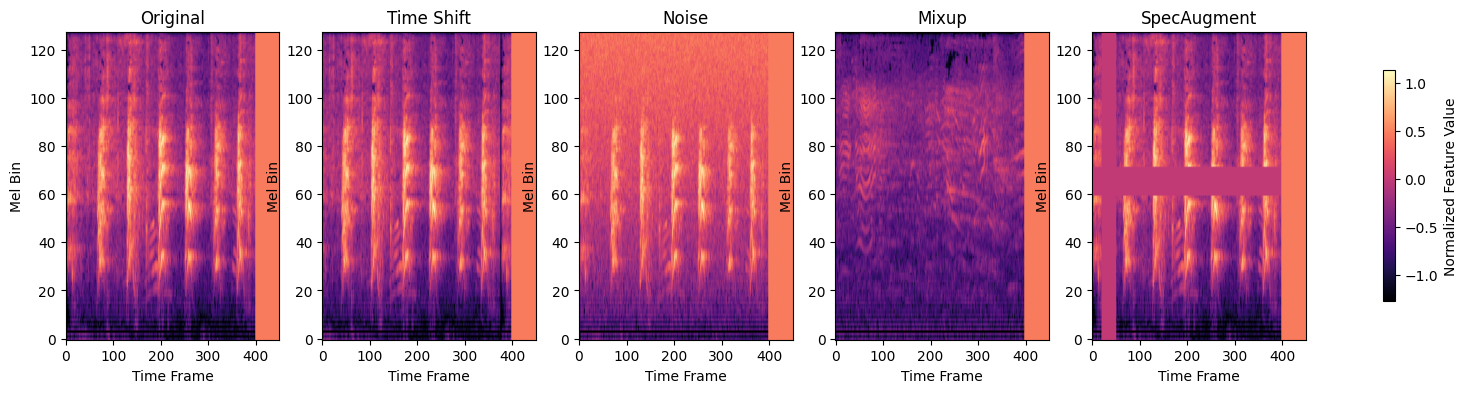


========== AUDIO PLAYBACK ==========
Original


Time Shift


Gaussian Noise (15 dB)


Mixup



========== AUGMENTED DATALOADER ==========
Train samples: 6970
Validation samples: 925
Test samples: 837
Input shape: (2, 1024, 128)
Hard label shape: (2,)
Soft label shape: (2, 10)

Augmented DataLoader verification PASSED!
Preprocessing and augmentation pipeline ready.


In [7]:

# ============================================================
# PROJECT 8: AST Preprocessing Verification + Augmentation
# UrbanSound8K | CPU Compatible | No Files Saved
# ============================================================

import random
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import torch

from torch.utils.data import Dataset, DataLoader
from transformers import AutoFeatureExtractor
from tqdm.auto import tqdm
from IPython.display import Audio, display

# ============================================================
# 1. CONFIGURATION
# ============================================================

ROOT = Path("/kaggle/input/datasets/chrisfilo/urbansound8k")
MODEL_NAME = "MIT/ast-finetuned-audioset-10-10-0.4593"

SEED = 42
SR = 16000
MAX_DURATION = 4.0
MAX_SAMPLES = int(SR * MAX_DURATION)
NUM_CLASSES = 10

TRAIN_FOLDS = [1, 2, 4, 5, 6, 7, 8, 9]
VAL_FOLDS = [3]
TEST_FOLDS = [10]

# Set False if you want to skip full verification
# after it has already passed once.
RUN_FULL_VERIFICATION = True

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

rng = np.random.default_rng(SEED)

df = pd.read_csv(ROOT / "UrbanSound8K.csv")

id2label = dict(
    zip(df["classID"], df["class"])
)

feature_extractor = AutoFeatureExtractor.from_pretrained(
    MODEL_NAME
)

assert feature_extractor.sampling_rate == SR
assert feature_extractor.num_mel_bins == 128
assert feature_extractor.max_length == 1024

print("========== CONFIGURATION ==========")
print("Total Audio:", len(df))
print("Sample Rate:", SR)
print("Max Duration:", MAX_DURATION)
print("AST Feature Shape: (1024, 128)")
print("Device: CPU compatible")


# ============================================================
# 2. WAVEFORM PREPROCESSING
# ============================================================

def preprocess_waveform(path):

    # Decode + mono conversion + 16 kHz resampling
    waveform, _ = librosa.load(
        str(path),
        sr=SR,
        mono=True,
        duration=MAX_DURATION
    )

    waveform = waveform[:MAX_SAMPLES]

    if len(waveform) == 0:
        raise ValueError("Empty waveform")

    return waveform.astype(np.float32)


def extract_ast_features(waveform):

    result = feature_extractor(
        waveform,
        sampling_rate=SR,
        return_tensors="np"
    )

    return np.asarray(
        result["input_values"][0],
        dtype=np.float32
    )


# ============================================================
# 3. FULL DATASET PREPROCESSING VERIFICATION
# ============================================================

if RUN_FULL_VERIFICATION:

    print("\n========== FULL DATASET VERIFICATION ==========")

    success = 0
    failures = []

    short_audio_count = 0
    min_duration = float("inf")
    max_duration = 0.0

    rows = df[
        ["slice_file_name", "fold", "classID"]
    ].itertuples(index=False, name=None)

    for filename, fold, class_id in tqdm(
        rows,
        total=len(df),
        desc="Verifying all audio"
    ):

        path = ROOT / f"fold{int(fold)}" / filename

        try:
            waveform = preprocess_waveform(path)

            duration = len(waveform) / SR

            # Waveform checks
            assert waveform.ndim == 1
            assert waveform.dtype == np.float32
            assert len(waveform) <= MAX_SAMPLES
            assert np.isfinite(waveform).all()

            # AST preprocessing
            features = extract_ast_features(waveform)

            assert features.shape == (1024, 128)
            assert np.isfinite(features).all()
            assert 0 <= int(class_id) < NUM_CLASSES

            success += 1

            min_duration = min(min_duration, duration)
            max_duration = max(max_duration, duration)

            if duration < 3.99:
                short_audio_count += 1

        except Exception as e:
            failures.append({
                "filename": filename,
                "fold": fold,
                "error": str(e)
            })

    print("\n========== VERIFICATION RESULTS ==========")

    print("Total Audio:", len(df))
    print("Successful:", success)
    print("Failed:", len(failures))
    print("Short Audio (<3.99s):", short_audio_count)

    if success > 0:
        print("Minimum Duration:", round(min_duration, 3))
        print("Maximum Duration:", round(max_duration, 3))

    if failures:
        print("\nFailed Samples:")
        display(pd.DataFrame(failures).head(20))
    else:
        print("\nAll audio preprocessing checks PASSED!")

    assert len(failures) == 0, (
        "Some audio files failed preprocessing."
    )


# ============================================================
# 4. AUGMENTATION: TIME SHIFT
# ============================================================

def time_shift_audio(waveform, rng, max_shift_sec=0.3):
    """
    Circularly shift audio without changing duration.
    Limit shift for very short audio.
    """

    max_shift = min(
        int(max_shift_sec * SR),
        max(1, len(waveform) // 4)
    )

    shift = int(
        rng.integers(-max_shift, max_shift + 1)
    )

    return np.roll(
        waveform, shift
    ).astype(np.float32)


# ============================================================
# 5. AUGMENTATION: BACKGROUND NOISE
# ============================================================

def add_background_noise(waveform, rng, snr_db=15):
    """
    Add synthetic white Gaussian noise at given SNR.

    Higher SNR -> less noise
    Lower SNR  -> more noise
    """

    signal_rms = np.sqrt(
        np.mean(waveform ** 2) + 1e-12
    )

    noise = rng.standard_normal(
        len(waveform)
    ).astype(np.float32)

    noise_rms = np.sqrt(
        np.mean(noise ** 2) + 1e-12
    )

    target_noise_rms = (
        signal_rms / (10 ** (snr_db / 20))
    )

    noise = noise * (
        target_noise_rms / noise_rms
    )

    return (waveform + noise).astype(np.float32)


# ============================================================
# 6. AUGMENTATION: MIXUP (WAVEFORM DOMAIN)
# ============================================================

def mixup_audio(
    waveform_a,
    label_a,
    waveform_b,
    label_b,
    rng,
    alpha=0.4
):
    """
    Combine two audio waveforms.

    Returns:
    - Mixed waveform
    - Soft label distribution
    - Mixing coefficient
    """

    length = max(
        len(waveform_a),
        len(waveform_b)
    )

    a = np.pad(
        waveform_a,
        (0, length - len(waveform_a))
    )

    b = np.pad(
        waveform_b,
        (0, length - len(waveform_b))
    )

    lam = float(rng.beta(alpha, alpha))

    mixed = (
        lam * a + (1 - lam) * b
    ).astype(np.float32)

    soft_labels = np.zeros(
        NUM_CLASSES,
        dtype=np.float32
    )

    soft_labels[int(label_a)] += lam
    soft_labels[int(label_b)] += 1 - lam

    return mixed, soft_labels, lam


# ============================================================
# 7. AUGMENTATION: SPECAUGMENT
# ============================================================

def spec_augment(features, rng):
    """
    Apply time masking and frequency masking
    on normalized AST Log-Mel features.

    Preserve AST's padded time frames.
    """

    augmented = features.copy()

    # AST pads features with 0 before normalization.
    # Find the normalized value of those padded frames.
    pad_value = (
        feature_extractor.padding_value
        - feature_extractor.mean
    ) / (2 * feature_extractor.std)

    is_padding = np.all(
        np.isclose(
            augmented,
            pad_value,
            atol=1e-4,
            rtol=0
        ),
        axis=1
    )

    real_indices = np.flatnonzero(~is_padding)

    if len(real_indices) == 0:
        return augmented

    valid_frames = int(real_indices[-1] + 1)

    # ----------------------------
    # Time Masking
    # ----------------------------

    max_time_width = min(
        40,
        max(1, valid_frames // 10)
    )

    time_width = int(
        rng.integers(1, max_time_width + 1)
    )

    time_start = int(
        rng.integers(
            0,
            valid_frames - time_width + 1
        )
    )

    augmented[
        time_start:time_start + time_width, :
    ] = 0.0

    # ----------------------------
    # Frequency Masking
    # ----------------------------

    max_freq_width = 12

    freq_width = int(
        rng.integers(1, max_freq_width + 1)
    )

    freq_start = int(
        rng.integers(
            0,
            augmented.shape[1] - freq_width + 1
        )
    )

    augmented[
        :valid_frames,
        freq_start:freq_start + freq_width
    ] = 0.0

    return augmented


# ============================================================
# 8. SELECT TWO TRAINING AUDIO SAMPLES
# ============================================================

df_train = df[
    df["fold"].isin(TRAIN_FOLDS)
].copy()

df_train["duration"] = (
    df_train["end"] - df_train["start"]
)

# Prefer a full-length dog bark sample
candidates_a = df_train[
    (df_train["class"] == "dog_bark")
    & (df_train["duration"] >= 3.8)
]

if candidates_a.empty:
    candidates_a = df_train[
        df_train["duration"] >= 3.8
    ]

row_a = candidates_a.iloc[0]

# Choose a different class for mixup
candidates_b = df_train[
    (df_train["classID"] != row_a["classID"])
    & (df_train["duration"] >= 3.8)
]

row_b = candidates_b.iloc[0]

path_a = (
    ROOT
    / f"fold{int(row_a['fold'])}"
    / row_a["slice_file_name"]
)

path_b = (
    ROOT
    / f"fold{int(row_b['fold'])}"
    / row_b["slice_file_name"]
)

audio_a = preprocess_waveform(path_a)
audio_b = preprocess_waveform(path_b)

label_a = int(row_a["classID"])
label_b = int(row_b["classID"])

print("\n========== SELECTED AUDIO ==========")
print("Audio A:", row_a["class"])
print("Audio B:", row_b["class"])


# ============================================================
# 9. APPLY ALL AUGMENTATIONS
# ============================================================

shifted_audio = time_shift_audio(
    audio_a, rng
)

noisy_audio = add_background_noise(
    audio_a,
    rng,
    snr_db=15
)

mixed_audio, mixed_labels, lam = mixup_audio(
    audio_a,
    label_a,
    audio_b,
    label_b,
    rng
)

# Extract features
original_features = extract_ast_features(audio_a)

shifted_features = extract_ast_features(
    shifted_audio
)

noisy_features = extract_ast_features(
    noisy_audio
)

mixed_features = extract_ast_features(
    mixed_audio
)

specaug_features = spec_augment(
    original_features,
    rng
)

# Verify augmentation
for name, features in [
    ("Original", original_features),
    ("Time Shift", shifted_features),
    ("Noise", noisy_features),
    ("Mixup", mixed_features),
    ("SpecAugment", specaug_features)
]:
    assert features.shape == (1024, 128)
    assert np.isfinite(features).all()

assert np.isclose(mixed_labels.sum(), 1.0)

print("\n========== AUGMENTATION VERIFICATION ==========")

print("Original Shape:", original_features.shape)
print("Shifted Shape:", shifted_features.shape)
print("Noisy Shape:", noisy_features.shape)
print("Mixup Shape:", mixed_features.shape)
print("SpecAugment Shape:", specaug_features.shape)

print("\nMixup lambda:", round(lam, 4))
print(
    row_a["class"],
    "target weight:",
    round(float(mixed_labels[label_a]), 4)
)
print(
    row_b["class"],
    "target weight:",
    round(float(mixed_labels[label_b]), 4)
)

print("\nAll augmentation checks PASSED!")


# ============================================================
# 10. WAVEFORM VISUALIZATION
# ============================================================

waveforms = [
    ("Original", audio_a),
    ("Time Shift", shifted_audio),
    ("Gaussian Noise (15 dB)", noisy_audio),
    ("Mixup", mixed_audio)
]

fig, axes = plt.subplots(
    4, 1, figsize=(13, 10)
)

for ax, (name, waveform) in zip(axes, waveforms):

    time_axis = np.arange(
        len(waveform)
    ) / SR

    ax.plot(time_axis, waveform, linewidth=0.7)

    ax.set_title(name)
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Amplitude")
    ax.set_xlim(0, MAX_DURATION)

plt.tight_layout()
plt.show()


# ============================================================
# 11. SPECTROGRAM VISUALIZATION
# ============================================================

spectrograms = [
    ("Original", original_features),
    ("Time Shift", shifted_features),
    ("Noise", noisy_features),
    ("Mixup", mixed_features),
    ("SpecAugment", specaug_features)
]

fig, axes = plt.subplots(
    1, 5, figsize=(20, 4)
)

# Show first 450 frames for clearer comparison.
# Full model input still has 1024 frames.
FRAMES_TO_SHOW = 450

vmin = float(original_features.min())
vmax = float(original_features.max())

for ax, (name, features) in zip(axes, spectrograms):

    im = ax.imshow(
        features[:FRAMES_TO_SHOW].T,
        origin="lower",
        aspect="auto",
        cmap="magma",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(name)
    ax.set_xlabel("Time Frame")
    ax.set_ylabel("Mel Bin")

fig.colorbar(
    im,
    ax=axes,
    label="Normalized Feature Value",
    shrink=0.75
)

plt.show()


# ============================================================
# 12. LISTEN TO ORIGINAL AND AUGMENTED AUDIO
# ============================================================

print("\n========== AUDIO PLAYBACK ==========")

for name, waveform in waveforms:

    print(name)

    display(
        Audio(
            np.clip(waveform, -1, 1),
            rate=SR,
            normalize=False
        )
    )


# ============================================================
# 13. TRAINING-ONLY AUGMENTATION DATASET
# ============================================================

class AugmentedUrbanSoundDataset(Dataset):

    def __init__(
        self,
        metadata,
        folds,
        training=False
    ):

        self.data = metadata[
            metadata["fold"].isin(folds)
        ].reset_index(drop=True)

        self.training = training

        # Prevent augmentation of validation/test folds
        if training:
            assert set(folds).issubset(
                set(TRAIN_FOLDS)
            )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        row = self.data.iloc[idx]

        path = (
            ROOT
            / f"fold{int(row['fold'])}"
            / row["slice_file_name"]
        )

        waveform = preprocess_waveform(path)
        label = int(row["classID"])

        # Always create a valid soft target
        soft_labels = np.zeros(
            NUM_CLASSES,
            dtype=np.float32
        )
        soft_labels[label] = 1.0

        if self.training:

            local_rng = np.random.default_rng(
                np.random.randint(0, 2**32 - 1)
            )

            # Time Shift
            if local_rng.random() < 0.5:
                waveform = time_shift_audio(
                    waveform, local_rng
                )

            # Gaussian Noise
            if local_rng.random() < 0.5:
                snr = float(
                    local_rng.uniform(10, 25)
                )
                waveform = add_background_noise(
                    waveform, local_rng, snr
                )

            # Mixup with another TRAINING sample
            if local_rng.random() < 0.35 and len(self.data) > 1:

                other_idx = int(
                    local_rng.integers(
                        0, len(self.data) - 1
                    )
                )

                if other_idx >= idx:
                    other_idx += 1

                other = self.data.iloc[other_idx]

                other_path = (
                    ROOT
                    / f"fold{int(other['fold'])}"
                    / other["slice_file_name"]
                )

                other_waveform = preprocess_waveform(
                    other_path
                )

                waveform, soft_labels, _ = mixup_audio(
                    waveform,
                    label,
                    other_waveform,
                    int(other["classID"]),
                    local_rng
                )

            features = extract_ast_features(waveform)

            # SpecAugment
            if local_rng.random() < 0.5:
                features = spec_augment(
                    features, local_rng
                )

        else:
            # Clean evaluation: no augmentation
            features = extract_ast_features(waveform)

        return {
            "input_values": torch.from_numpy(
                features.copy()
            ),
            "labels": torch.tensor(
                label, dtype=torch.long
            ),
            "soft_labels": torch.from_numpy(
                soft_labels.copy()
            )
        }


train_aug_dataset = AugmentedUrbanSoundDataset(
    df, TRAIN_FOLDS, training=True
)

val_clean_dataset = AugmentedUrbanSoundDataset(
    df, VAL_FOLDS, training=False
)

test_clean_dataset = AugmentedUrbanSoundDataset(
    df, TEST_FOLDS, training=False
)

# Verify one augmented training batch
train_aug_loader = DataLoader(
    train_aug_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0
)

train_batch = next(iter(train_aug_loader))

print("\n========== AUGMENTED DATALOADER ==========")
print("Train samples:", len(train_aug_dataset))
print("Validation samples:", len(val_clean_dataset))
print("Test samples:", len(test_clean_dataset))

print(
    "Input shape:",
    tuple(train_batch["input_values"].shape)
)

print(
    "Hard label shape:",
    tuple(train_batch["labels"].shape)
)

print(
    "Soft label shape:",
    tuple(train_batch["soft_labels"].shape)
)

assert train_batch["input_values"].shape == (
    2, 1024, 128
)

assert torch.allclose(
    train_batch["soft_labels"].sum(dim=1),
    torch.ones(2),
    atol=1e-5
)

print("\nAugmented DataLoader verification PASSED!")
print("Preprocessing and augmentation pipeline ready.")


In [8]:

# ============================================================
# PROJECT 8: UrbanSound8K
# PyTorch Dataset + DataLoader
# ============================================================

import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from torch.utils.data import Dataset, DataLoader

# ============================================================
# 1. CONFIGURATION
# ============================================================

ROOT = Path("/kaggle/input/datasets/chrisfilo/urbansound8k")

SEED = 42
BATCH_SIZE = 2
NUM_WORKERS = 0
NUM_CLASSES = 10
SR = 16000

TRAIN_FOLDS = [1, 2, 4, 5, 6, 7, 8, 9]
VAL_FOLDS = [3]
TEST_FOLDS = [10]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

df = pd.read_csv(ROOT / "UrbanSound8K.csv")

id2label = dict(
    df[["classID", "class"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)

# Reuse functions from the previous preprocessing cell.
required_functions = [
    "preprocess_waveform",
    "extract_ast_features",
    "add_background_noise",
    "mixup_audio",
    "spec_augment"
]

missing = [
    name for name in required_functions
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Run the previous preprocessing/augmentation "
        f"cell first. Missing: {missing}"
    )


# ============================================================
# 2. ZERO-FILLED TIME SHIFT
# ============================================================

def zero_filled_time_shift(waveform, rng, max_sec=0.25):
    """
    Shift audio left/right without circular wrapping.
    Vacated positions are filled with zeros.
    """

    n = len(waveform)

    max_shift = min(
        int(max_sec * SR),
        max(1, n // 4)
    )

    shift = int(
        rng.integers(-max_shift, max_shift + 1)
    )

    shifted = np.zeros_like(waveform)

    if shift > 0:
        shifted[shift:] = waveform[:-shift]

    elif shift < 0:
        shifted[:shift] = waveform[-shift:]

    else:
        shifted = waveform.copy()

    return shifted.astype(np.float32)


# ============================================================
# 3. DATASET CLASS
# ============================================================

class UrbanSoundASTDataset(Dataset):

    def __init__(self, metadata, folds, training=False):

        self.training = training

        selected = metadata[
            metadata["fold"].isin(folds)
        ].reset_index(drop=True)

        self.samples = []

        for filename, fold, class_id in selected[
            ["slice_file_name", "fold", "classID"]
        ].itertuples(index=False, name=None):

            path = (
                ROOT
                / f"fold{int(fold)}"
                / filename
            )

            self.samples.append(
                (path, int(class_id))
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        path, label = self.samples[idx]

        # ------------------------------------
        # A. Load and preprocess waveform
        # ------------------------------------

        waveform = preprocess_waveform(path)

        # Default: one-hot target
        soft_labels = np.zeros(
            NUM_CLASSES, dtype=np.float32
        )
        soft_labels[label] = 1.0

        # ------------------------------------
        # B. Training-only augmentation
        # ------------------------------------

        if self.training:

            rng = np.random.default_rng(
                random.getrandbits(64)
            )

            # 1. Time Shift
            if rng.random() < 0.5:

                waveform = zero_filled_time_shift(
                    waveform, rng
                )

            # 2. Background Noise
            if rng.random() < 0.5:

                snr = float(
                    rng.uniform(10, 25)
                )

                waveform = add_background_noise(
                    waveform,
                    rng,
                    snr_db=snr
                )

            # 3. Mixup
            if (
                rng.random() < 0.35
                and len(self.samples) > 1
            ):

                other_idx = int(
                    rng.integers(
                        0, len(self.samples) - 1
                    )
                )

                if other_idx >= idx:
                    other_idx += 1

                other_path, other_label = (
                    self.samples[other_idx]
                )

                other_waveform = preprocess_waveform(
                    other_path
                )

                waveform, soft_labels, _ = mixup_audio(
                    waveform,
                    label,
                    other_waveform,
                    other_label,
                    rng,
                    alpha=0.4
                )

        # ------------------------------------
        # C. AST Feature Extraction
        # ------------------------------------

        features = extract_ast_features(waveform)

        if isinstance(features, torch.Tensor):
            features = features.detach().cpu().numpy()

        features = np.asarray(
            features, dtype=np.float32
        )

        # ------------------------------------
        # D. SpecAugment (Training Only)
        # ------------------------------------

        if self.training and rng.random() < 0.5:

            features = spec_augment(
                features, rng
            )

        # ------------------------------------
        # E. Return PyTorch Tensors
        # ------------------------------------

        return {
            "input_values": torch.from_numpy(
                np.ascontiguousarray(features)
            ),

            "labels": torch.tensor(
                label,
                dtype=torch.long
            ),

            "soft_labels": torch.from_numpy(
                soft_labels.copy()
            )
        }


# ============================================================
# 4. CREATE TRAIN / VAL / TEST DATASETS
# ============================================================

train_dataset = UrbanSoundASTDataset(
    df,
    folds=TRAIN_FOLDS,
    training=True
)

val_dataset = UrbanSoundASTDataset(
    df,
    folds=VAL_FOLDS,
    training=False
)

test_dataset = UrbanSoundASTDataset(
    df,
    folds=TEST_FOLDS,
    training=False
)

# Check source-level overlap
def source_ids(folds):
    return set(
        df.loc[df["fold"].isin(folds), "fsID"]
    )

train_ids = source_ids(TRAIN_FOLDS)
val_ids = source_ids(VAL_FOLDS)
test_ids = source_ids(TEST_FOLDS)

assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)

print("========== DATASET INFORMATION ==========")

print("Training Samples:", len(train_dataset))
print("Validation Samples:", len(val_dataset))
print("Testing Samples:", len(test_dataset))
print("Total Samples:", len(train_dataset)
      + len(val_dataset) + len(test_dataset))

print("\nSource-level leakage check PASSED!")


# ============================================================
# 5. WORKER SEEDING
# ============================================================

def seed_worker(worker_id):

    worker_seed = torch.initial_seed() % (2**32)

    np.random.seed(worker_seed)
    random.seed(worker_seed)


generator = torch.Generator()
generator.manual_seed(SEED)


# ============================================================
# 6. CREATE DATALOADERS
# ============================================================

loader_config = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
    "worker_init_fn": seed_worker
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=generator,
    **loader_config
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_config
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_config
)

print("\n========== DATALOADER INFORMATION ==========")

print("Training Batches:", len(train_loader))
print("Validation Batches:", len(val_loader))
print("Testing Batches:", len(test_loader))


# ============================================================
# 7. VERIFY TRAINING BATCH
# ============================================================

train_batch = next(iter(train_loader))

inputs = train_batch["input_values"]
labels = train_batch["labels"]
soft_labels = train_batch["soft_labels"]

print("\n========== TRAINING BATCH ==========")

print("Input Shape:", tuple(inputs.shape))
print("Input Dtype:", inputs.dtype)

print("Hard Labels Shape:", tuple(labels.shape))
print("Hard Labels:", labels.tolist())

print("Soft Labels Shape:", tuple(soft_labels.shape))
print("Soft Labels:")
print(soft_labels)

assert inputs.shape == (BATCH_SIZE, 1024, 128)
assert labels.shape == (BATCH_SIZE,)
assert soft_labels.shape == (BATCH_SIZE, NUM_CLASSES)

assert torch.isfinite(inputs).all()
assert torch.isfinite(soft_labels).all()

assert torch.allclose(
    soft_labels.sum(dim=1),
    torch.ones(BATCH_SIZE),
    atol=1e-5
)

print("\nTraining batch verification PASSED!")


# ============================================================
# 8. VERIFY VALIDATION / TEST BATCHES
# ============================================================

for name, loader in [
    ("Validation", val_loader),
    ("Test", test_loader)
]:

    batch = next(iter(loader))

    x = batch["input_values"]
    y = batch["labels"]
    soft = batch["soft_labels"]

    assert x.shape[1:] == (1024, 128)
    assert torch.isfinite(x).all()

    # Clean samples must have one-hot labels
    assert torch.allclose(
        soft.sum(dim=1),
        torch.ones(len(y))
    )

    assert torch.equal(
        soft.argmax(dim=1),
        y
    )

    print(f"\n========== {name.upper()} BATCH ==========")

    print("Input Shape:", tuple(x.shape))
    print("Labels:", y.tolist())

    print(f"{name} batch verification PASSED!")


# ============================================================
# 9. FINAL SUMMARY
# ============================================================

print("\n========== FINAL SUMMARY ==========")

print("Dataset: UrbanSound8K")
print("Model Input: AST Log-Mel Features")
print("Feature Shape: (1024, 128)")
print("Batch Size:", BATCH_SIZE)

print("\nTraining Augmentation: ENABLED")
print("Validation Augmentation: DISABLED")
print("Test Augmentation: DISABLED")

print("\nDataset and DataLoader are ready!")


========== DATASET INFORMATION ==========
Training Samples: 6970
Validation Samples: 925
Testing Samples: 837
Total Samples: 8732

Source-level leakage check PASSED!

========== DATALOADER INFORMATION ==========
Training Batches: 3485
Validation Batches: 463
Testing Batches: 419

========== TRAINING BATCH ==========
Input Shape: (2, 1024, 128)
Input Dtype: torch.float32
Hard Labels Shape: (2,)
Hard Labels: [2, 3]
Soft Labels Shape: (2, 10)
Soft Labels:
tensor([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]])

Training batch verification PASSED!

========== VALIDATION BATCH ==========
Input Shape: (2, 1024, 128)
Labels: [3, 4]
Validation batch verification PASSED!

========== TEST BATCH ==========
Input Shape: (2, 1024, 128)
Labels: [1, 1]
Test batch verification PASSED!

========== FINAL SUMMARY ==========
Dataset: UrbanSound8K
Model Input: AST Log-Mel Features
Feature Shape: (1024, 128)
Batch Size: 2

Training Augmentation: ENABLED
Validatio

In [9]:

# ============================================================
# PROJECT 8: AUDIO SPECTROGRAM TRANSFORMER (AST)
# Pretrained Backbone + 10-Class Classification Head
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import ASTForAudioClassification

# ============================================================
# 1. MODEL CONFIGURATION
# ============================================================

MODEL_NAME = "MIT/ast-finetuned-audioset-10-10-0.4593"

NUM_CLASSES = 10

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Start with frozen backbone.
# Later use "full" for complete fine-tuning.
FINETUNE_MODE = "head_only"

# Full forward pass is optional on CPU.
RUN_FORWARD_TEST = False

print("========== CONFIGURATION ==========")
print("Device:", DEVICE)
print("Model:", MODEL_NAME)
print("Classes:", NUM_CLASSES)
print("Fine-tuning Mode:", FINETUNE_MODE)


# ============================================================
# 2. VERIFY CLASS MAPPING
# ============================================================

assert "id2label" in globals(), (
    "Run the Dataset/DataLoader cell first."
)

id2label = {
    int(k): str(v)
    for k, v in id2label.items()
}

label2id = {
    name: idx
    for idx, name in id2label.items()
}

assert len(id2label) == NUM_CLASSES
assert set(id2label.keys()) == set(range(NUM_CLASSES))


# ============================================================
# 3. LOAD PRETRAINED AST
# ============================================================

model = ASTForAudioClassification.from_pretrained(
    MODEL_NAME,

    num_labels=NUM_CLASSES,

    id2label=id2label,
    label2id=label2id,

    # Replace original AudioSet classification head
    ignore_mismatched_sizes=True
)

model.config.problem_type = (
    "single_label_classification"
)

model = model.to(DEVICE)

print("\nPretrained AST loaded successfully!")


# ============================================================
# 4. CONFIGURE TRAINABLE LAYERS
# ============================================================

def set_finetune_mode(model, mode="head_only"):

    if mode not in ["head_only", "full"]:
        raise ValueError(
            "mode must be 'head_only' or 'full'"
        )

    # First, enable every parameter
    for param in model.parameters():
        param.requires_grad = True

    if mode == "head_only":

        # Freeze pretrained AST backbone
        for param in (
            model.audio_spectrogram_transformer.parameters()
        ):
            param.requires_grad = False

    return model


model = set_finetune_mode(
    model,
    FINETUNE_MODE
)

# Set evaluation mode for verification
model.eval()


# ============================================================
# 5. PRINT MODEL ARCHITECTURE
# ============================================================

print("\n========== MODEL ARCHITECTURE ==========")

print("\nBackbone:")
print(type(model.audio_spectrogram_transformer).__name__)

print("\nClassification Head:")
print(model.classifier)

print("\n========== TRANSFORMER CONFIG ==========")

print("Hidden Size:", model.config.hidden_size)
print("Transformer Layers:", model.config.num_hidden_layers)
print("Attention Heads:", model.config.num_attention_heads)
print("Patch Size:", model.config.patch_size)
print("Output Classes:", model.config.num_labels)


# ============================================================
# 6. PARAMETER COUNT
# ============================================================

total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

frozen_params = total_params - trainable_params

print("\n========== MODEL PARAMETERS ==========")

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Frozen Parameters: {frozen_params:,}")

print(
    "Trainable Percentage:",
    f"{100 * trainable_params / total_params:.2f}%"
)


# ============================================================
# 7. VERIFY CLASSIFICATION HEAD
# ============================================================

# Lightweight test, suitable for CPU.
# Test only the head, not the whole AST backbone.

hidden_size = model.config.hidden_size

dummy_features = torch.zeros(
    2,
    hidden_size,
    device=DEVICE
)

with torch.inference_mode():
    head_logits = model.classifier(dummy_features)

print("\n========== CLASSIFICATION HEAD TEST ==========")

print("Input Shape:", tuple(dummy_features.shape))
print("Output Shape:", tuple(head_logits.shape))

assert head_logits.shape == (2, NUM_CLASSES)
assert torch.isfinite(head_logits).all()

print("Classification head verification PASSED!")


# ============================================================
# 8. OPTIONAL FULL FORWARD PASS
# ============================================================

if RUN_FORWARD_TEST:

    assert "val_loader" in globals(), (
        "Run DataLoader cell first."
    )

    batch = next(iter(val_loader))

    # Use only one sample to reduce CPU workload
    input_values = batch["input_values"][:1].to(DEVICE)

    with torch.inference_mode():

        outputs = model(
            input_values=input_values
        )

        logits = outputs.logits

        probabilities = F.softmax(
            logits,
            dim=-1
        )

    print("\n========== FULL FORWARD TEST ==========")

    print("Input Shape:", tuple(input_values.shape))
    print("Logits Shape:", tuple(logits.shape))
    print("Probabilities Shape:", tuple(probabilities.shape))

    assert logits.shape == (1, NUM_CLASSES)

    print("\nPredictions (untrained head):")

    top_probs, top_indices = torch.topk(
        probabilities[0],
        k=3
    )

    for class_id, probability in zip(
        top_indices.tolist(),
        top_probs.tolist()
    ):

        print(
            f"{id2label[class_id]}: "
            f"{probability * 100:.2f}%"
        )

    print("\nFull forward pass PASSED!")

else:
    print("\nFull forward test skipped.")
    print("Set RUN_FORWARD_TEST=True to enable it.")


# ============================================================
# 9. FINAL VERIFICATION
# ============================================================

assert model.config.num_labels == NUM_CLASSES

assert model.classifier.dense.out_features == NUM_CLASSES

print("\n========== FINAL STATUS ==========")

print("Pretrained AST Backbone: READY")
print("10-Class Classification Head: READY")
print("Fine-tuning Mode:", FINETUNE_MODE)
print("Model Device:", DEVICE)

print("\nMODEL INITIALIZATION COMPLETED!")


========== CONFIGURATION ==========
Device: cuda
Model: MIT/ast-finetuned-audioset-10-10-0.4593
Classes: 10
Fine-tuning Mode: head_only


[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `527`.


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

[transformers] ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                          
------------------------+----------+------------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([10])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.



Pretrained AST loaded successfully!

========== MODEL ARCHITECTURE ==========

Backbone:
ASTModel

Classification Head:
ASTMLPHead(
  (layernorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
  (dense): Linear(in_features=768, out_features=10, bias=True)
)

========== TRANSFORMER CONFIG ==========
Hidden Size: 768
Transformer Layers: 12
Attention Heads: 12
Patch Size: 16
Output Classes: 10

========== MODEL PARAMETERS ==========
Total Parameters: 86,196,490
Trainable Parameters: 9,226
Frozen Parameters: 86,187,264
Trainable Percentage: 0.01%

========== CLASSIFICATION HEAD TEST ==========
Input Shape: (2, 768)
Output Shape: (2, 10)
Classification head verification PASSED!

Full forward test skipped.
Set RUN_FORWARD_TEST=True to enable it.

========== FINAL STATUS ==========
Pretrained AST Backbone: READY
10-Class Classification Head: READY
Fine-tuning Mode: head_only
Model Device: cuda

MODEL INITIALIZATION COMPLETED!


In [10]:

# ============================================================
# PROJECT 8: AST LOSS + OPTIMIZER + SCHEDULER + HELPERS
# ============================================================

import math
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from sklearn.metrics import accuracy_score, f1_score

# ============================================================
# 1. CONFIGURATION
# ============================================================

assert "model" in globals(), "Run the Model cell first."
assert "train_loader" in globals(), "Run the DataLoader cell first."

DEVICE = next(model.parameters()).device

NUM_CLASSES = 10
EPOCHS = 10

BACKBONE_LR = 1e-5
HEAD_LR = 1e-4
WEIGHT_DECAY = 0.01

GRAD_ACCUM_STEPS = 2
MAX_GRAD_NORM = 1.0
WARMUP_RATIO = 0.05

USE_AMP = DEVICE.type == "cuda"

print("========== TRAINING CONFIGURATION ==========")
print("Device:", DEVICE)
print("Epochs:", EPOCHS)
print("Backbone LR:", BACKBONE_LR)
print("Head LR:", HEAD_LR)
print("Weight Decay:", WEIGHT_DECAY)
print("Gradient Accumulation:", GRAD_ACCUM_STEPS)
print("Mixed Precision:", USE_AMP)


# ============================================================
# 2. LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss()


def compute_loss(logits, batch, training=True):
    """
    Training:
        Soft-label CE (supports Mixup)

    Validation/Test:
        Standard CE with hard labels
    """

    logits = logits.float()

    if training:
        targets = batch["soft_labels"].to(
            device=logits.device,
            dtype=torch.float32
        )

        loss = criterion(logits, targets)

    else:
        targets = batch["labels"].to(
            device=logits.device,
            dtype=torch.long
        )

        loss = criterion(logits, targets)

    return loss


# ============================================================
# 3. OPTIMIZER PARAMETER GROUPS
# ============================================================

def create_optimizer(model):

    parameter_groups = []

    modules = [
        (
            "backbone",
            model.audio_spectrogram_transformer,
            BACKBONE_LR
        ),
        (
            "head",
            model.classifier,
            HEAD_LR
        )
    ]

    for module_name, module, learning_rate in modules:

        decay_params = []
        no_decay_params = []

        for name, param in module.named_parameters():

            if not param.requires_grad:
                continue

            # Biases and normalization parameters:
            # no weight decay
            if param.ndim < 2 or name.endswith(".bias"):
                no_decay_params.append(param)
            else:
                decay_params.append(param)

        if decay_params:
            parameter_groups.append({
                "params": decay_params,
                "lr": learning_rate,
                "weight_decay": WEIGHT_DECAY,
                "group_name": f"{module_name}_decay"
            })

        if no_decay_params:
            parameter_groups.append({
                "params": no_decay_params,
                "lr": learning_rate,
                "weight_decay": 0.0,
                "group_name": f"{module_name}_no_decay"
            })

    if not parameter_groups:
        raise ValueError("No trainable model parameters found.")

    return AdamW(
        parameter_groups,
        betas=(0.9, 0.999),
        eps=1e-8
    )


optimizer = create_optimizer(model)

# Verify all trainable parameters are included
trainable_count = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

optimizer_count = sum(
    p.numel()
    for group in optimizer.param_groups
    for p in group["params"]
)

assert trainable_count == optimizer_count

print("\n========== OPTIMIZER ==========")
print("Optimizer: AdamW")
print("Trainable Parameters:", f"{trainable_count:,}")

for group in optimizer.param_groups:
    print(
        f"{group['group_name']}: "
        f"LR={group['lr']:.2e}, "
        f"WD={group['weight_decay']}"
    )


# ============================================================
# 4. LEARNING RATE SCHEDULER
# ============================================================

# Scheduler steps once per optimizer update,
# not once per DataLoader batch.

UPDATES_PER_EPOCH = math.ceil(
    len(train_loader) / GRAD_ACCUM_STEPS
)

TOTAL_UPDATES = UPDATES_PER_EPOCH * EPOCHS

WARMUP_UPDATES = int(
    TOTAL_UPDATES * WARMUP_RATIO
)


def lr_multiplier(step):

    # Linear warmup
    if WARMUP_UPDATES > 0 and step < WARMUP_UPDATES:
        return (step + 1) / WARMUP_UPDATES

    # Cosine decay
    progress = (
        (step - WARMUP_UPDATES)
        / max(1, TOTAL_UPDATES - WARMUP_UPDATES)
    )

    progress = min(1.0, max(0.0, progress))

    cosine = 0.5 * (
        1.0 + math.cos(math.pi * progress)
    )

    # Minimum 1% of peak learning rate
    return 0.01 + 0.99 * cosine


scheduler = LambdaLR(
    optimizer,
    lr_lambda=lr_multiplier
)

print("\n========== LR SCHEDULER ==========")
print("Scheduler: Linear Warmup + Cosine Decay")
print("Optimizer Updates/Epoch:", UPDATES_PER_EPOCH)
print("Total Optimizer Updates:", TOTAL_UPDATES)
print("Warmup Updates:", WARMUP_UPDATES)


# ============================================================
# 5. MIXED PRECISION SCALER
# ============================================================

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

# On CPU, GradScaler stays disabled.
# On CUDA, it supports mixed-precision training.


# ============================================================
# 6. HELPER: MOVE BATCH TO DEVICE
# ============================================================

def prepare_batch(batch, device=DEVICE):

    return {
        "input_values": batch["input_values"].to(
            device, non_blocking=device.type == "cuda"
        ),
        "labels": batch["labels"].to(
            device, non_blocking=device.type == "cuda"
        ),
        "soft_labels": batch["soft_labels"].to(
            device, non_blocking=device.type == "cuda"
        )
    }


# ============================================================
# 7. HELPER: GRADIENT CLIPPING
# ============================================================

def clip_gradients(model):

    return torch.nn.utils.clip_grad_norm_(
        (
            p for p in model.parameters()
            if p.requires_grad
        ),
        max_norm=MAX_GRAD_NORM
    )


# ============================================================
# 8. HELPER: EVALUATION METRICS
# ============================================================

def compute_metrics(all_labels, all_predictions):
    """
    Use aggregated predictions from an entire
    validation/test epoch, not mixed training labels.
    """

    return {
        "accuracy": accuracy_score(
            all_labels,
            all_predictions
        ),

        "macro_f1": f1_score(
            all_labels,
            all_predictions,
            labels=list(range(NUM_CLASSES)),
            average="macro",
            zero_division=0
        )
    }


# ============================================================
# 9. HELPER: CURRENT LEARNING RATES
# ============================================================

def get_learning_rates():

    return {
        group["group_name"]: group["lr"]
        for group in optimizer.param_groups
    }


# ============================================================
# 10. LOSS FUNCTION VERIFICATION (CPU ONLY)
# ============================================================

print("\n========== LOSS VERIFICATION ==========")

# Simulate two model predictions
dummy_logits = torch.randn(
    2, NUM_CLASSES,
    requires_grad=True
)

# Hard labels
dummy_labels = torch.tensor([3, 2])

# Soft labels: simulate Mixup
dummy_soft = F.one_hot(
    dummy_labels,
    num_classes=NUM_CLASSES
).float()

# First sample: 70% dog_bark + 30% children_playing
dummy_soft[0] = 0.0
dummy_soft[0, 3] = 0.7
dummy_soft[0, 2] = 0.3

dummy_batch = {
    "labels": dummy_labels,
    "soft_labels": dummy_soft
}

# Training loss
train_loss = compute_loss(
    dummy_logits,
    dummy_batch,
    training=True
)

# Validation loss
val_loss = compute_loss(
    dummy_logits,
    dummy_batch,
    training=False
)

# Test gradient computation
train_loss.backward()

assert torch.isfinite(train_loss)
assert torch.isfinite(val_loss)
assert dummy_logits.grad is not None
assert torch.isfinite(dummy_logits.grad).all()

print("Training Loss:", round(train_loss.item(), 4))
print("Validation Loss:", round(val_loss.item(), 4))
print("Gradient Computation: PASSED")

# No optimizer step is performed on the real AST model.


# ============================================================
# 11. FINAL SUMMARY
# ============================================================

print("\n========== FINAL SUMMARY ==========")

print("Loss Function: READY")
print("AdamW Optimizer: READY")
print("LR Scheduler: READY")
print("Gradient Scaler: READY")
print("Gradient Clipping Helper: READY")
print("Metrics Helper: READY")

print("\nCurrent Learning Rates:")
for name, lr in get_learning_rates().items():
    print(f"{name}: {lr:.8f}")

print("\nTraining components initialized successfully!")
print("No actual model training performed.")


========== TRAINING CONFIGURATION ==========
Device: cuda:0
Epochs: 10
Backbone LR: 1e-05
Head LR: 0.0001
Weight Decay: 0.01
Gradient Accumulation: 2
Mixed Precision: True

========== OPTIMIZER ==========
Optimizer: AdamW
Trainable Parameters: 9,226
head_decay: LR=1.00e-04, WD=0.01
head_no_decay: LR=1.00e-04, WD=0.0

========== LR SCHEDULER ==========
Scheduler: Linear Warmup + Cosine Decay
Optimizer Updates/Epoch: 1743
Total Optimizer Updates: 17430
Warmup Updates: 871

========== LOSS VERIFICATION ==========
Training Loss: 4.465
Validation Loss: 4.8914
Gradient Computation: PASSED

========== FINAL SUMMARY ==========
Loss Function: READY
AdamW Optimizer: READY
LR Scheduler: READY
Gradient Scaler: READY
Gradient Clipping Helper: READY
Metrics Helper: READY

Current Learning Rates:
head_decay: 0.00000011
head_no_decay: 0.00000011

Training components initialized successfully!
No actual model training performed.


In [11]:

# ============================================================
# PROJECT 8: AST COMPLETE TRAINING PIPELINE
# Train + Validation + Early Stopping + History
# ============================================================

import math
import time
from itertools import islice

import pandas as pd
import matplotlib.pyplot as plt
import torch

from tqdm.auto import tqdm


# ============================================================
# 1. TRAINING CONFIGURATION
# ============================================================

# True  = run only 2 train and 2 validation batches
# False = train on all batches for EPOCHS epochs
SMOKE_TEST = True

# CPU training is disabled by default because AST is large.
# Set True only if you explicitly want to test on CPU.
ALLOW_CPU_TRAINING = False

PATIENCE = 3
MIN_DELTA = 1e-4

TRAIN_EPOCHS = 1 if SMOKE_TEST else EPOCHS

MAX_TRAIN_BATCHES = 2 if SMOKE_TEST else None
MAX_VAL_BATCHES = 2 if SMOKE_TEST else None

# Reuse the device assigned to the model
DEVICE = next(model.parameters()).device

USE_AMP = DEVICE.type == "cuda"

RUN_TRAINING = (
    DEVICE.type == "cuda"
    or ALLOW_CPU_TRAINING
)

print("========== TRAINING CONFIGURATION ==========")
print("Device:", DEVICE)
print("Smoke Test:", SMOKE_TEST)
print("Epochs:", TRAIN_EPOCHS)
print("Gradient Accumulation:", GRAD_ACCUM_STEPS)
print("Mixed Precision:", USE_AMP)
print("Early Stopping Patience:", PATIENCE)


# ============================================================
# 2. VERIFY REQUIRED COMPONENTS
# ============================================================

required_components = [
    "model",
    "train_loader",
    "val_loader",
    "optimizer",
    "scheduler",
    "scaler",
    "compute_loss",
    "prepare_batch",
    "clip_gradients",
    "compute_metrics",
    "get_learning_rates"
]

missing = [
    name for name in required_components
    if name not in globals()
]

if missing:
    raise RuntimeError(
        f"Run previous cells first. Missing: {missing}"
    )

# Check optimizer includes all trainable parameters
trainable_ids = {
    id(p)
    for p in model.parameters()
    if p.requires_grad
}

optimizer_ids_list = [
    id(p)
    for group in optimizer.param_groups
    for p in group["params"]
]

assert len(optimizer_ids_list) == len(
    set(optimizer_ids_list)
), "Duplicate optimizer parameters found."

assert set(optimizer_ids_list) == trainable_ids, (
    "Optimizer does not match the trainable parameters. "
    "Rerun the Loss/Optimizer cell after changing "
    "the fine-tuning mode."
)

assert model.config.num_labels == 10

if RUN_TRAINING:
    assert scaler.is_enabled() == USE_AMP, (
        "GradScaler does not match the current device. "
        "Rerun the Loss/Optimizer cell."
    )

print("\nComponent verification passed!")


# ============================================================
# 3. TRAIN ONE EPOCH
# ============================================================

def train_one_epoch(loader, max_batches=None):

    model.train()

    # Keep frozen backbone in evaluation mode
    # so pretrained dropout behavior stays stable.
    backbone = model.audio_spectrogram_transformer

    if not any(
        p.requires_grad for p in backbone.parameters()
    ):
        backbone.eval()

    total_loss = 0.0
    total_samples = 0
    optimizer_updates = 0

    num_batches = len(loader)

    if max_batches is not None:
        num_batches = min(num_batches, max_batches)

    optimizer.zero_grad(set_to_none=True)

    progress = tqdm(
        islice(loader, num_batches),
        total=num_batches,
        desc="Training",
        leave=False
    )

    for step, raw_batch in enumerate(progress):

        # ------------------------------------
        # A. Move batch to device
        # ------------------------------------

        batch = prepare_batch(
            raw_batch,
            device=DEVICE
        )

        inputs = batch["input_values"]

        # ------------------------------------
        # B. Forward pass + loss
        # ------------------------------------

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=USE_AMP
        ):

            outputs = model(
                input_values=inputs
            )

            # Soft-label CE supports Mixup
            loss = compute_loss(
                outputs.logits,
                batch,
                training=True
            )

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Non-finite training loss at batch {step}"
            )

        # ------------------------------------
        # C. Gradient accumulation
        # ------------------------------------

        group_start = (
            step // GRAD_ACCUM_STEPS
        ) * GRAD_ACCUM_STEPS

        group_size = min(
            GRAD_ACCUM_STEPS,
            num_batches - group_start
        )

        scaled_loss = loss / group_size

        scaler.scale(scaled_loss).backward()

        should_update = (
            (step + 1) % GRAD_ACCUM_STEPS == 0
            or (step + 1) == num_batches
        )

        if should_update:

            # Unscale before clipping
            scaler.unscale_(optimizer)

            clip_gradients(model)

            # Save scale to detect skipped AMP updates
            previous_scale = scaler.get_scale()

            scaler.step(optimizer)
            scaler.update()

            update_successful = (
                not USE_AMP
                or scaler.get_scale() >= previous_scale
            )

            # Scheduler advances only after a
            # successful optimizer update.
            if update_successful:
                scheduler.step()
                optimizer_updates += 1

            optimizer.zero_grad(set_to_none=True)

        # ------------------------------------
        # D. Loss tracking
        # ------------------------------------

        batch_size = inputs.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        progress.set_postfix({
            "loss": f"{total_loss / total_samples:.4f}"
        })

    avg_loss = total_loss / total_samples

    return {
        "loss": avg_loss,
        "samples": total_samples,
        "optimizer_updates": optimizer_updates
    }


# ============================================================
# 4. VALIDATE ONE EPOCH
# ============================================================

def validate_one_epoch(loader, max_batches=None):

    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_predictions = []

    num_batches = len(loader)

    if max_batches is not None:
        num_batches = min(num_batches, max_batches)

    progress = tqdm(
        islice(loader, num_batches),
        total=num_batches,
        desc="Validation",
        leave=False
    )

    with torch.inference_mode():

        for raw_batch in progress:

            batch = prepare_batch(
                raw_batch,
                device=DEVICE
            )

            inputs = batch["input_values"]
            labels = batch["labels"]

            # ------------------------------------
            # A. Forward pass
            # ------------------------------------

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=USE_AMP
            ):

                outputs = model(
                    input_values=inputs
                )

                logits = outputs.logits

                # Standard hard-label CE
                loss = compute_loss(
                    logits,
                    batch,
                    training=False
                )

            if not torch.isfinite(loss):
                raise RuntimeError(
                    "Non-finite validation loss detected."
                )

            # ------------------------------------
            # B. Predictions
            # ------------------------------------

            predictions = logits.argmax(dim=1)

            all_labels.extend(
                labels.cpu().tolist()
            )

            all_predictions.extend(
                predictions.cpu().tolist()
            )

            # ------------------------------------
            # C. Loss tracking
            # ------------------------------------

            batch_size = labels.size(0)

            total_loss += loss.item() * batch_size
            total_samples += batch_size

    avg_loss = total_loss / total_samples

    metrics = compute_metrics(
        all_labels,
        all_predictions
    )

    return {
        "loss": avg_loss,
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "samples": total_samples
    }


# ============================================================
# 5. EARLY STOPPING + BEST WEIGHTS IN MEMORY
# ============================================================

class EarlyStopping:

    def __init__(self, patience=3, min_delta=1e-4):

        self.patience = patience
        self.min_delta = min_delta

        self.best_score = -float("inf")
        self.best_epoch = 0
        self.counter = 0

        self.best_parameters = None

    def step(self, score, epoch, model):

        improved = (
            score > self.best_score + self.min_delta
        )

        # Always capture the first epoch
        if self.best_parameters is None:
            improved = True

        if improved:

            self.best_score = score
            self.best_epoch = epoch
            self.counter = 0

            # Store trainable parameters only in CPU RAM.
            # Frozen AST parameters remain unchanged.
            self.best_parameters = {
                name: param.detach().cpu().clone()
                for name, param in model.named_parameters()
                if param.requires_grad
            }

        else:
            self.counter += 1

        should_stop = (
            self.counter >= self.patience
        )

        return should_stop

    def restore_best(self, model):

        if self.best_parameters is None:
            return

        with torch.no_grad():

            for name, param in model.named_parameters():

                if name in self.best_parameters:

                    param.copy_(
                        self.best_parameters[name].to(
                            device=param.device,
                            dtype=param.dtype
                        )
                    )


# ============================================================
# 6. COMPLETE TRAINING LOOP
# ============================================================

def fit_model():

    early_stopper = EarlyStopping(
        patience=PATIENCE,
        min_delta=MIN_DELTA
    )

    history = []

    start_time = time.time()

    print("\n========== TRAINING STARTED ==========")

    for epoch in range(1, TRAIN_EPOCHS + 1):

        print(f"\nEpoch {epoch}/{TRAIN_EPOCHS}")

        # ------------------------------------
        # Training
        # ------------------------------------

        train_result = train_one_epoch(
            train_loader,
            max_batches=MAX_TRAIN_BATCHES
        )

        # ------------------------------------
        # Validation
        # ------------------------------------

        val_result = validate_one_epoch(
            val_loader,
            max_batches=MAX_VAL_BATCHES
        )

        # ------------------------------------
        # Record metrics
        # ------------------------------------

        current_lrs = get_learning_rates()

        head_lr = next(
            (
                lr
                for name, lr in current_lrs.items()
                if name.startswith("head")
            ),
            0.0
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_result["loss"],
            "val_loss": val_result["loss"],
            "val_accuracy": val_result["accuracy"],
            "val_macro_f1": val_result["macro_f1"],
            "head_lr": head_lr
        })

        print(
            f"Train Loss: {train_result['loss']:.4f}"
        )

        print(
            f"Val Loss:   {val_result['loss']:.4f}"
        )

        print(
            f"Val Acc:    {val_result['accuracy']:.4f}"
        )

        print(
            f"Val F1:     {val_result['macro_f1']:.4f}"
        )

        print(
            f"Optimizer Updates: "
            f"{train_result['optimizer_updates']}"
        )

        print(f"Head LR: {head_lr:.8f}")

        # ------------------------------------
        # Early stopping
        # ------------------------------------

        if not SMOKE_TEST:

            should_stop = early_stopper.step(
                val_result["macro_f1"],
                epoch,
                model
            )

            print(
                "Best Val Macro-F1:",
                f"{early_stopper.best_score:.4f}"
            )

            if should_stop:

                print(
                    f"\nEarly stopping at epoch {epoch}."
                )

                break

    # ========================================================
    # RESTORE BEST TRAINABLE PARAMETERS
    # ========================================================

    if not SMOKE_TEST:

        early_stopper.restore_best(model)

        print("\nBest model parameters restored.")

        print(
            "Best Epoch:",
            early_stopper.best_epoch
        )

        print(
            "Best Validation Macro-F1:",
            f"{early_stopper.best_score:.4f}"
        )

    model.eval()

    elapsed = (time.time() - start_time) / 60

    history_df = pd.DataFrame(history)

    print("\n========== TRAINING FINISHED ==========")
    print(f"Total Time: {elapsed:.2f} minutes")

    if SMOKE_TEST:
        print(
            "SMOKE TEST ONLY: metrics are not "
            "representative of model performance."
        )

    print("Held-out test set has NOT been evaluated.")
    print("No model files were saved.")

    print("\nTraining History:")
    display(history_df)

    return history_df


# ============================================================
# 7. EXECUTE TRAINING
# ============================================================

if RUN_TRAINING:

    history_df = fit_model()

    # ========================================================
    # 8. VISUALIZE TRAINING HISTORY
    # ========================================================

    if len(history_df) > 1:

        fig, axes = plt.subplots(
            1, 2,
            figsize=(13, 4)
        )

        # Loss curves
        axes[0].plot(
            history_df["epoch"],
            history_df["train_loss"],
            marker="o",
            label="Training Loss"
        )

        axes[0].plot(
            history_df["epoch"],
            history_df["val_loss"],
            marker="o",
            label="Validation Loss"
        )

        axes[0].set_title("Training vs Validation Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        # Validation metrics
        axes[1].plot(
            history_df["epoch"],
            history_df["val_accuracy"],
            marker="o",
            label="Validation Accuracy"
        )

        axes[1].plot(
            history_df["epoch"],
            history_df["val_macro_f1"],
            marker="o",
            label="Validation Macro-F1"
        )

        axes[1].set_title("Validation Performance")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Score")
        axes[1].set_ylim(0, 1.05)
        axes[1].legend()
        axes[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

else:

    print("\n========== TRAINING NOT STARTED ==========")

    print("Training functions are ready.")
    print("Current device:", DEVICE)

    print(
        "CPU-only mode: training intentionally skipped."
    )

    print(
        "Enable Kaggle GPU and rerun Model, "
        "Optimizer, and Training cells."
    )

print("\nTraining pipeline setup completed!")


========== TRAINING CONFIGURATION ==========
Device: cuda:0
Smoke Test: True
Epochs: 1
Gradient Accumulation: 2
Mixed Precision: True
Early Stopping Patience: 3

Component verification passed!

========== TRAINING STARTED ==========

Epoch 1/1


Training:   0%|          | 0/2 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Train Loss: 1.9504
Val Loss:   2.9858
Val Acc:    0.0000
Val F1:     0.0000
Optimizer Updates: 1
Head LR: 0.00000023

========== TRAINING FINISHED ==========
Total Time: 0.01 minutes
SMOKE TEST ONLY: metrics are not representative of model performance.
Held-out test set has NOT been evaluated.
No model files were saved.

Training History:


,epoch,train_loss,val_loss,val_accuracy,val_macro_f1,head_lr
0,1,1.950428,2.985764,0.0,0.0,2.296211e-07



Training pipeline setup completed!


========== CONFIGURATION ==========
Device: cuda
GPU: Tesla T4
Epochs: 10
Training Samples: 6970
Validation Samples: 925
Batch Size: 2
Effective Batch Size: 4


[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `527`.


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

[transformers] ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                          
------------------------+----------+------------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([10])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.



========== MODEL ==========
Architecture: AST
Backbone: FROZEN
Classification Head: TRAINABLE
Trainable Parameters: 9,226

========== OPTIMIZATION ==========
Optimizer: AdamW
Peak Head LR: 0.0001
Warmup Updates: 871
Total Planned Updates: 17430
Gradient Accumulation: 2
Mixed Precision: Enabled

========== FULL TRAINING STARTED ==========


...


========== EPOCH 4/10 ==========
Train Loss: 0.5257
Val Loss:   0.4852
Val Accuracy: 0.8259
Val Macro-F1: 0.8391
Learning Rate: 0.00007042
Epoch Time: 4.55 minutes
Epochs without improvement: 2
Best Macro-F1: 0.8554


Train 5/10:   0%|          | 0/3485 [00:00<?, ?it/s]

Validation:   0%|          | 0/463 [00:00<?, ?it/s]


========== EPOCH 5/10 ==========
Train Loss: 0.4805
Val Loss:   0.4777
Val Accuracy: 0.8259
Val Macro-F1: 0.8403
Learning Rate: 0.00005463
Epoch Time: 4.52 minutes
Epochs without improvement: 3
Best Macro-F1: 0.8554

Early stopping triggered at epoch 5.

========== TRAINING COMPLETED ==========
Best Epoch: 2
Best Validation Macro-F1: 0.8554
Total Training Time: 22.86 min
Best classification head restored in memory.
Test fold has NOT been evaluated.
No files were saved.

========== TRAINING HISTORY ==========


,epoch,train_loss,val_loss,val_accuracy,val_macro_f1,learning_rate,minutes
0,1,1.2365,0.5151,0.8422,0.8547,0.0001,4.6020
1,2,0.5943,0.4620,0.8400,0.8554,0.0001,4.6071
2,3,0.5483,0.4779,0.8205,0.8327,0.0001,4.5749
3,4,0.5257,0.4852,0.8259,0.8391,0.0001,4.5480
4,5,0.4805,0.4777,0.8259,0.8403,0.0001,4.5243


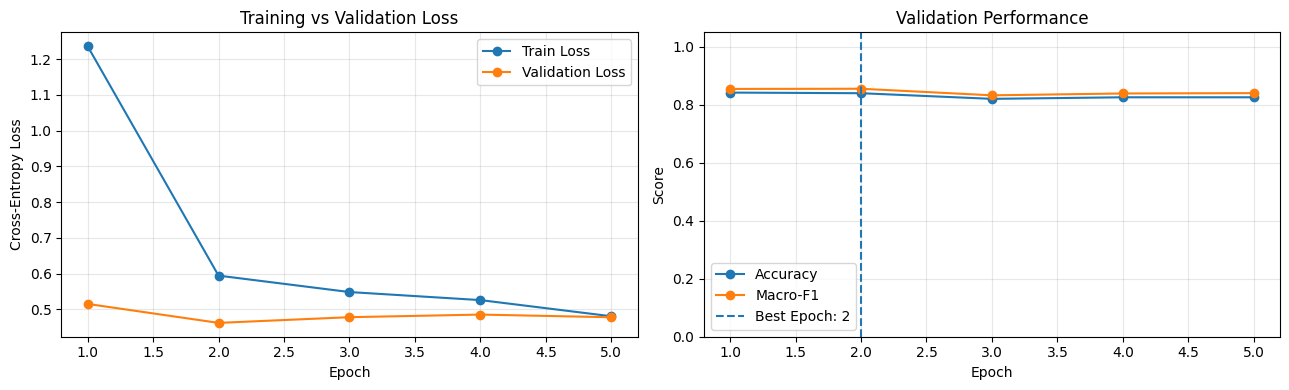


AST HEAD-ONLY TRAINING FINISHED!


In [12]:

# ============================================================
# PROJECT 8: URBANSOUND8K - FULL AST TRAINING
# Phase 1: Frozen AST Backbone + Trainable 10-Class Head
# ============================================================

import gc
import math
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from transformers import ASTForAudioClassification
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm
from IPython.display import display


# ============================================================
# 1. CONFIGURATION
# ============================================================

MODEL_NAME = "MIT/ast-finetuned-audioset-10-10-0.4593"

SEED = 42
NUM_CLASSES = 10

EPOCHS = 10
HEAD_LR = 1e-4
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.05

GRAD_ACCUM_STEPS = 2
MAX_GRAD_NORM = 1.0

PATIENCE = 3
MIN_DELTA = 1e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

if DEVICE.type != "cuda":
    raise RuntimeError(
        "Full AST training requires a GPU. "
        "Enable Kaggle GPU first."
    )

assert "train_loader" in globals()
assert "val_loader" in globals()
assert "id2label" in globals()

assert len(train_loader.dataset) == 6970
assert len(val_loader.dataset) == 925

assert train_loader.dataset.training is True
assert val_loader.dataset.training is False

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if train_loader.generator is not None:
    train_loader.generator.manual_seed(SEED)

print("========== CONFIGURATION ==========")
print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))
print("Epochs:", EPOCHS)
print("Training Samples:", len(train_loader.dataset))
print("Validation Samples:", len(val_loader.dataset))
print("Batch Size:", train_loader.batch_size)
print(
    "Effective Batch Size:",
    train_loader.batch_size * GRAD_ACCUM_STEPS
)


# ============================================================
# 2. FRESH MODEL INITIALIZATION
# ============================================================

# Remove old smoke-test model/optimizer from memory.
# The new run must start from fresh pretrained weights.

for name in ("optimizer", "scheduler", "scaler", "model"):
    globals().pop(name, None)

gc.collect()
torch.cuda.empty_cache()

model = ASTForAudioClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    id2label={
        int(k): str(v)
        for k, v in id2label.items()
    },
    label2id={
        str(v): int(k)
        for k, v in id2label.items()
    },
    ignore_mismatched_sizes=True
)

model.config.problem_type = "single_label_classification"

# Freeze pretrained backbone
for param in model.audio_spectrogram_transformer.parameters():
    param.requires_grad = False

# Train only classification head
for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(DEVICE)

trainable_params = [
    p for p in model.parameters()
    if p.requires_grad
]

print("\n========== MODEL ==========")
print("Architecture: AST")
print("Backbone: FROZEN")
print("Classification Head: TRAINABLE")

print(
    "Trainable Parameters:",
    f"{sum(p.numel() for p in trainable_params):,}"
)


# ============================================================
# 3. FRESH ADAMW OPTIMIZER
# ============================================================

decay_params = []
no_decay_params = []

for name, param in model.classifier.named_parameters():

    if not param.requires_grad:
        continue

    if param.ndim < 2 or name.endswith(".bias"):
        no_decay_params.append(param)
    else:
        decay_params.append(param)

optimizer = AdamW(
    [
        {
            "params": decay_params,
            "lr": HEAD_LR,
            "weight_decay": WEIGHT_DECAY
        },
        {
            "params": no_decay_params,
            "lr": HEAD_LR,
            "weight_decay": 0.0
        }
    ],
    betas=(0.9, 0.999),
    eps=1e-8
)


# ============================================================
# 4. WARMUP + COSINE LEARNING RATE SCHEDULER
# ============================================================

UPDATES_PER_EPOCH = math.ceil(
    len(train_loader) / GRAD_ACCUM_STEPS
)

TOTAL_UPDATES = UPDATES_PER_EPOCH * EPOCHS

WARMUP_UPDATES = max(
    1,
    int(TOTAL_UPDATES * WARMUP_RATIO)
)


def lr_lambda(step):

    if step < WARMUP_UPDATES:
        return (step + 1) / WARMUP_UPDATES

    progress = (
        (step - WARMUP_UPDATES)
        / max(1, TOTAL_UPDATES - WARMUP_UPDATES)
    )

    progress = min(1.0, max(0.0, progress))

    cosine = 0.5 * (
        1.0 + math.cos(math.pi * progress)
    )

    return 0.01 + 0.99 * cosine


scheduler = LambdaLR(
    optimizer,
    lr_lambda=lr_lambda
)

scaler = torch.amp.GradScaler("cuda")

print("\n========== OPTIMIZATION ==========")
print("Optimizer: AdamW")
print("Peak Head LR:", HEAD_LR)
print("Warmup Updates:", WARMUP_UPDATES)
print("Total Planned Updates:", TOTAL_UPDATES)
print("Gradient Accumulation:", GRAD_ACCUM_STEPS)
print("Mixed Precision: Enabled")


# ============================================================
# 5. TRAIN ONE EPOCH
# ============================================================

def train_one_epoch(epoch):

    model.train()

    # Keep the frozen backbone in eval mode.
    model.audio_spectrogram_transformer.eval()

    total_loss = 0.0
    total_samples = 0
    successful_updates = 0

    num_batches = len(train_loader)

    optimizer.zero_grad(set_to_none=True)

    progress = tqdm(
        enumerate(train_loader),
        total=num_batches,
        desc=f"Train {epoch}/{EPOCHS}"
    )

    for step, batch in progress:

        inputs = batch["input_values"].to(
            DEVICE,
            non_blocking=True
        )

        soft_labels = batch["soft_labels"].to(
            DEVICE,
            dtype=torch.float32,
            non_blocking=True
        )

        # ------------------------------------
        # Forward Pass
        # ------------------------------------

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(
                input_values=inputs
            )

            logits = outputs.logits

            # Mixup-compatible Soft-Label CE
            loss = F.cross_entropy(
                logits.float(),
                soft_labels
            )

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Non-finite training loss at batch {step}"
            )

        # ------------------------------------
        # Gradient Accumulation
        # ------------------------------------

        group_start = (
            step // GRAD_ACCUM_STEPS
        ) * GRAD_ACCUM_STEPS

        group_size = min(
            GRAD_ACCUM_STEPS,
            num_batches - group_start
        )

        scaler.scale(
            loss / group_size
        ).backward()

        should_update = (
            (step + 1) % GRAD_ACCUM_STEPS == 0
            or step + 1 == num_batches
        )

        if should_update:

            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                trainable_params,
                max_norm=MAX_GRAD_NORM
            )

            previous_scale = scaler.get_scale()

            scaler.step(optimizer)
            scaler.update()

            # Skip scheduler update if AMP skipped
            # the optimizer step due to overflow.
            if scaler.get_scale() >= previous_scale:
                scheduler.step()
                successful_updates += 1

            optimizer.zero_grad(set_to_none=True)

        # ------------------------------------
        # Loss Tracking
        # ------------------------------------

        batch_size = inputs.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        progress.set_postfix({
            "loss": f"{total_loss / total_samples:.4f}",
            "lr": f"{optimizer.param_groups[0]['lr']:.2e}"
        })

    return {
        "loss": total_loss / total_samples,
        "updates": successful_updates
    }


# ============================================================
# 6. VALIDATE ONE EPOCH
# ============================================================

@torch.inference_mode()
def validate_one_epoch():

    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_predictions = []

    progress = tqdm(
        val_loader,
        desc="Validation",
        leave=False
    )

    for batch in progress:

        inputs = batch["input_values"].to(
            DEVICE,
            non_blocking=True
        )

        labels = batch["labels"].to(
            DEVICE,
            non_blocking=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            logits = model(
                input_values=inputs
            ).logits

            # Hard-label CE: no augmentation
            loss = F.cross_entropy(
                logits.float(),
                labels
            )

        if not torch.isfinite(loss):
            raise RuntimeError(
                "Non-finite validation loss."
            )

        predictions = logits.argmax(dim=1)

        all_labels.extend(
            labels.cpu().tolist()
        )

        all_predictions.extend(
            predictions.cpu().tolist()
        )

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        labels=list(range(NUM_CLASSES)),
        average="macro",
        zero_division=0
    )

    return {
        "loss": total_loss / total_samples,
        "accuracy": accuracy,
        "macro_f1": macro_f1
    }


# ============================================================
# 7. FULL TRAINING LOOP + EARLY STOPPING
# ============================================================

history = []

best_f1 = -float("inf")
best_epoch = 0
best_head_state = None

epochs_without_improvement = 0

training_start = time.time()

print("\n========== FULL TRAINING STARTED ==========")

for epoch in range(1, EPOCHS + 1):

    epoch_start = time.time()

    # ------------------------------------
    # Training
    # ------------------------------------

    train_metrics = train_one_epoch(epoch)

    # ------------------------------------
    # Validation
    # ------------------------------------

    val_metrics = validate_one_epoch()

    elapsed = (time.time() - epoch_start) / 60

    current_lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "learning_rate": current_lr,
        "minutes": elapsed
    })

    # ------------------------------------
    # Print Epoch Results
    # ------------------------------------

    print(f"\n========== EPOCH {epoch}/{EPOCHS} ==========")

    print(
        f"Train Loss: {train_metrics['loss']:.4f}"
    )

    print(
        f"Val Loss:   {val_metrics['loss']:.4f}"
    )

    print(
        f"Val Accuracy: {val_metrics['accuracy']:.4f}"
    )

    print(
        f"Val Macro-F1: {val_metrics['macro_f1']:.4f}"
    )

    print(f"Learning Rate: {current_lr:.8f}")
    print(f"Epoch Time: {elapsed:.2f} minutes")

    # ------------------------------------
    # Best Model Selection
    # ------------------------------------

    if val_metrics["macro_f1"] > best_f1 + MIN_DELTA:

        best_f1 = val_metrics["macro_f1"]
        best_epoch = epoch

        epochs_without_improvement = 0

        # Store best classification head in RAM.
        # No file is created.
        best_head_state = {
            name: tensor.detach().cpu().clone()
            for name, tensor
            in model.classifier.state_dict().items()
        }

        print("New best validation Macro-F1!")

    else:

        epochs_without_improvement += 1

        print(
            "Epochs without improvement:",
            epochs_without_improvement
        )

    print(f"Best Macro-F1: {best_f1:.4f}")

    # ------------------------------------
    # Early Stopping
    # ------------------------------------

    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping triggered at epoch {epoch}."
        )

        break


# ============================================================
# 8. RESTORE BEST MODEL
# ============================================================

assert best_head_state is not None

model.classifier.load_state_dict(
    best_head_state
)

model.eval()

training_minutes = (
    time.time() - training_start
) / 60

print("\n========== TRAINING COMPLETED ==========")

print("Best Epoch:", best_epoch)
print(f"Best Validation Macro-F1: {best_f1:.4f}")
print(f"Total Training Time: {training_minutes:.2f} min")
print("Best classification head restored in memory.")
print("Test fold has NOT been evaluated.")
print("No files were saved.")


# ============================================================
# 9. TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(history)

print("\n========== TRAINING HISTORY ==========")

display(history_df.round(4))


# ============================================================
# 10. TRAINING VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 4)
)

# Training / Validation Loss
axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train Loss"
)

axes[0].plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Validation Metrics
axes[1].plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    marker="o",
    label="Accuracy"
)

axes[1].plot(
    history_df["epoch"],
    history_df["val_macro_f1"],
    marker="o",
    label="Macro-F1"
)

axes[1].axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)

axes[1].set_title("Validation Performance")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAST HEAD-ONLY TRAINING FINISHED!")


========== TEST CONFIGURATION ==========
Device: cuda:0
Model: AST Head-Only
Test Fold: 10
Test Samples: 837
Test Batches: 419
Augmentation: Disabled
Best Training Epoch: 2

Starting held-out test evaluation...


Evaluating Test Set:   0%|          | 0/419 [00:00<?, ?it/s]


Inference completed successfully!

========== OVERALL TEST RESULTS ==========
Test Loss:        0.3519
Test Accuracy:    0.8937 (89.37%)
Macro Precision:  0.9137
Macro Recall:     0.9016
Macro F1:         0.9039
Weighted F1:      0.8954
Top-3 Accuracy:   0.9689

Correct Predictions: 748
Wrong Predictions:   89
Total Samples:       837

========== CLASSIFICATION REPORT ==========
                  precision    recall  f1-score   support

 air_conditioner     0.6641    0.8500    0.7456       100
        car_horn     0.9118    0.9394    0.9254        33
children_playing     0.8522    0.9800    0.9116       100
        dog_bark     0.9551    0.8500    0.8995       100
        drilling     0.9570    0.8900    0.9223       100
   engine_idling     0.9213    0.8817    0.9011        93
        gun_shot     1.0000    1.0000    1.0000        32
      jackhammer     0.9794    0.9896    0.9845        96
           siren     0.9683    0.7349    0.8356        83
    street_music     0.9278    0.900

,Class,Precision,Recall,F1,Support
0,air_conditioner,0.6641,0.8500,0.7456,100
8,siren,0.9683,0.7349,0.8356,83
3,dog_bark,0.9551,0.8500,0.8995,100
5,engine_idling,0.9213,0.8817,0.9011,93
2,children_playing,0.8522,0.9800,0.9116,100
9,street_music,0.9278,0.9000,0.9137,100
4,drilling,0.9570,0.8900,0.9223,100
1,car_horn,0.9118,0.9394,0.9254,33
7,jackhammer,0.9794,0.9896,0.9845,96
6,gun_shot,1.0000,1.0000,1.0000,32


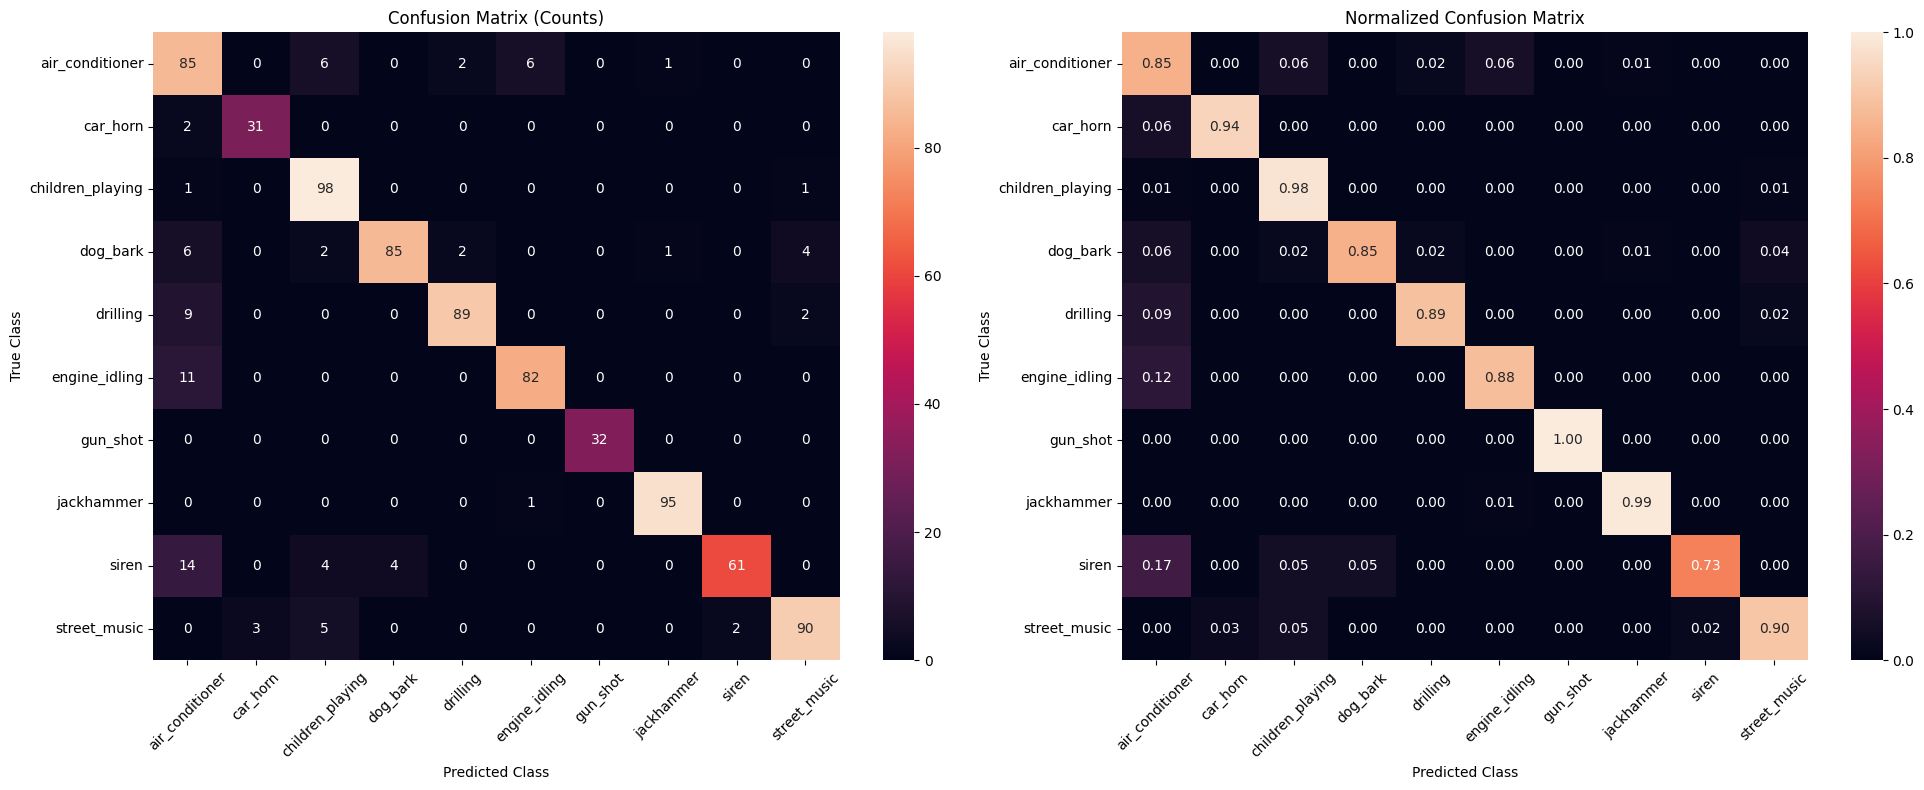

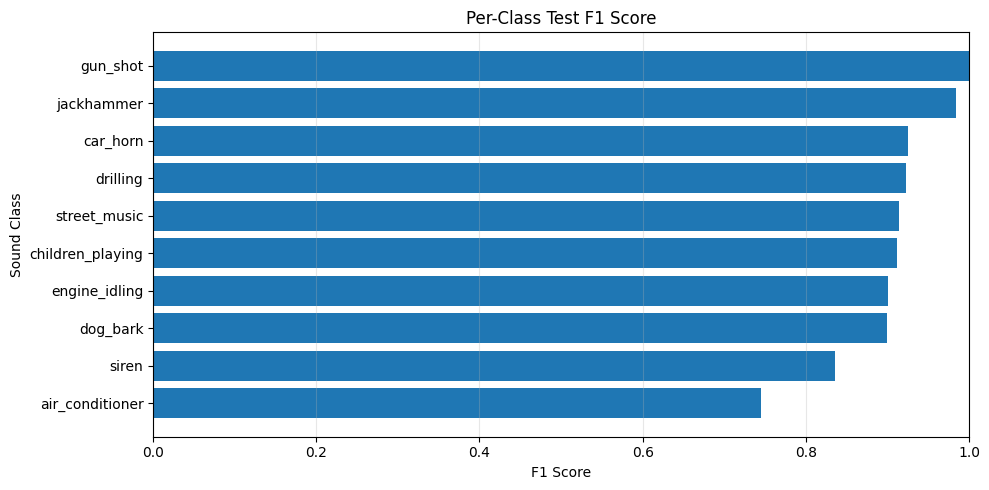


========== MOST CONFUSED CLASSES ==========


,True Class,Predicted Class,Mistakes
16,siren,air_conditioner,14
14,engine_idling,air_conditioner,11
12,drilling,air_conditioner,9
7,dog_bark,air_conditioner,6
0,air_conditioner,children_playing,6
2,air_conditioner,engine_idling,6
20,street_music,children_playing,5
17,siren,children_playing,4
11,dog_bark,street_music,4
18,siren,dog_bark,4



========== HIGH-CONFIDENCE ERRORS ==========


,filename,true_class,predicted_class,confidence_percent
734,77927-3-1-1.wav,dog_bark,street_music,99.54
352,171478-9-0-38.wav,street_music,children_playing,97.20
105,119067-0-0-2.wav,air_conditioner,engine_idling,96.85
104,119067-0-0-1.wav,air_conditioner,engine_idling,96.22
733,77927-3-0-2.wav,dog_bark,street_music,92.99
125,136558-9-1-21.wav,street_music,car_horn,92.46
103,119067-0-0-0.wav,air_conditioner,engine_idling,91.76
95,118558-5-0-2.wav,engine_idling,air_conditioner,87.61
94,118558-5-0-1.wav,engine_idling,air_conditioner,87.04
93,118558-5-0-0.wav,engine_idling,air_conditioner,86.88



========== FINAL TEST SUMMARY ==========
Model: AST (Frozen Backbone + Trained Head)
Test Fold: 10
Test Samples: 837

Accuracy:    89.37%
Macro-F1:    0.9039
Weighted-F1: 0.8954
Top-3 Acc:   96.89%

Test evaluation completed!
No optimizer updates performed.
No files saved.


In [13]:

# ============================================================
# PROJECT 8: AST TEST SET EVALUATION
# UrbanSound8K | Fold 10 | No Training | No Files Saved
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

from contextlib import nullcontext
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. VERIFY TRAINED MODEL AND TEST LOADER
# ============================================================

required = ["model", "test_loader", "id2label"]

missing = [
    name for name in required
    if name not in globals()
]

if missing:
    raise RuntimeError(
        f"Missing components: {missing}. "
        "Run previous Dataset and Training cells first."
    )

DEVICE = next(model.parameters()).device
NUM_CLASSES = 10
CLASS_IDS = list(range(NUM_CLASSES))

class_names = [
    str(id2label[i])
    for i in CLASS_IDS
]

assert model.config.num_labels == NUM_CLASSES

# Ensure test data has no augmentation
assert not getattr(
    test_loader.dataset, "training", False
), "Test augmentation must be disabled."

# Ensure sequential evaluation for correct file alignment
assert isinstance(
    test_loader.sampler,
    torch.utils.data.SequentialSampler
), "Test DataLoader must use shuffle=False."

assert len(test_loader.dataset) == 837

# Verify all test files originate from fold10
test_samples = getattr(
    test_loader.dataset, "samples", None
)

if test_samples is not None:
    assert all(
        path.parent.name == "fold10"
        for path, label in test_samples
    )

model.eval()

print("========== TEST CONFIGURATION ==========")
print("Device:", DEVICE)
print("Model: AST Head-Only")
print("Test Fold: 10")
print("Test Samples:", len(test_loader.dataset))
print("Test Batches:", len(test_loader))
print("Augmentation: Disabled")

if "best_epoch" in globals():
    print("Best Training Epoch:", best_epoch)

print("\nStarting held-out test evaluation...")


# ============================================================
# 2. TEST INFERENCE
# ============================================================

all_labels = []
all_predictions = []
all_confidences = []
all_top3_indices = []

total_loss = 0.0
total_samples = 0

def autocast_context():
    if DEVICE.type == "cuda":
        return torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        )
    return nullcontext()


with torch.inference_mode():

    for batch in tqdm(
        test_loader,
        desc="Evaluating Test Set"
    ):

        inputs = batch["input_values"].to(
            DEVICE,
            non_blocking=DEVICE.type == "cuda"
        )

        labels = batch["labels"].to(
            DEVICE,
            non_blocking=DEVICE.type == "cuda"
        )

        # Forward pass
        with autocast_context():

            outputs = model(
                input_values=inputs
            )

            logits = outputs.logits

        # Standard Cross-Entropy for test labels
        loss = F.cross_entropy(
            logits.float(),
            labels
        )

        if not torch.isfinite(loss):
            raise RuntimeError(
                "Non-finite test loss detected."
            )

        # Convert logits to class scores
        probabilities = torch.softmax(
            logits.float(),
            dim=1
        )

        # Top-1 prediction
        predictions = probabilities.argmax(dim=1)

        # Top-3 predictions
        top3_probs, top3_ids = torch.topk(
            probabilities,
            k=3,
            dim=1
        )

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        all_labels.extend(
            labels.cpu().tolist()
        )

        all_predictions.extend(
            predictions.cpu().tolist()
        )

        all_confidences.extend(
            top3_probs[:, 0].cpu().tolist()
        )

        all_top3_indices.extend(
            top3_ids.cpu().tolist()
        )


# ============================================================
# 3. BASIC VERIFICATION
# ============================================================

assert total_samples == len(test_loader.dataset)
assert len(all_labels) == total_samples
assert len(all_predictions) == total_samples
assert len(all_confidences) == total_samples

# Check predictions against Dataset sample order
if test_samples is not None:
    expected_labels = [
        int(label)
        for path, label in test_samples
    ]
    assert all_labels == expected_labels

print("\nInference completed successfully!")


# ============================================================
# 4. OVERALL TEST METRICS
# ============================================================

test_loss = total_loss / total_samples

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

test_precision = precision_score(
    all_labels,
    all_predictions,
    labels=CLASS_IDS,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    all_labels,
    all_predictions,
    labels=CLASS_IDS,
    average="macro",
    zero_division=0
)

test_macro_f1 = f1_score(
    all_labels,
    all_predictions,
    labels=CLASS_IDS,
    average="macro",
    zero_division=0
)

test_weighted_f1 = f1_score(
    all_labels,
    all_predictions,
    labels=CLASS_IDS,
    average="weighted",
    zero_division=0
)

# Top-3 accuracy
top3_correct = sum(
    label in top3
    for label, top3 in zip(
        all_labels,
        all_top3_indices
    )
)

test_top3_accuracy = (
    top3_correct / total_samples
)

correct_count = sum(
    true == pred
    for true, pred in zip(
        all_labels,
        all_predictions
    )
)

print("\n========== OVERALL TEST RESULTS ==========")

print(f"Test Loss:        {test_loss:.4f}")
print(f"Test Accuracy:    {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Macro Precision:  {test_precision:.4f}")
print(f"Macro Recall:     {test_recall:.4f}")
print(f"Macro F1:         {test_macro_f1:.4f}")
print(f"Weighted F1:      {test_weighted_f1:.4f}")
print(f"Top-3 Accuracy:   {test_top3_accuracy:.4f}")

print(f"\nCorrect Predictions: {correct_count}")
print(f"Wrong Predictions:   {total_samples - correct_count}")
print(f"Total Samples:       {total_samples}")


# ============================================================
# 5. PER-CLASS CLASSIFICATION REPORT
# ============================================================

print("\n========== CLASSIFICATION REPORT ==========")

report = classification_report(
    all_labels,
    all_predictions,
    labels=CLASS_IDS,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

# Structured per-class results
report_dict = classification_report(
    all_labels,
    all_predictions,
    labels=CLASS_IDS,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

per_class_df = pd.DataFrame([
    {
        "Class": name,
        "Precision": report_dict[name]["precision"],
        "Recall": report_dict[name]["recall"],
        "F1": report_dict[name]["f1-score"],
        "Support": int(report_dict[name]["support"])
    }
    for name in class_names
])

print("\n========== PER-CLASS PERFORMANCE ==========")

display(
    per_class_df.sort_values(
        "F1",
        ascending=True
    ).round(4)
)


# ============================================================
# 6. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=CLASS_IDS
)

cm_normalized = confusion_matrix(
    all_labels,
    all_predictions,
    labels=CLASS_IDS,
    normalize="true"
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(20, 8)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)

axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("True Class")

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    xticklabels=class_names,
    yticklabels=class_names,
    vmin=0,
    vmax=1,
    ax=axes[1]
)

axes[1].set_title("Normalized Confusion Matrix")
axes[1].set_xlabel("Predicted Class")
axes[1].set_ylabel("True Class")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()


# ============================================================
# 7. PER-CLASS F1 VISUALIZATION
# ============================================================

sorted_df = per_class_df.sort_values("F1")

plt.figure(figsize=(10, 5))

plt.barh(
    sorted_df["Class"],
    sorted_df["F1"]
)

plt.xlim(0, 1)
plt.xlabel("F1 Score")
plt.ylabel("Sound Class")
plt.title("Per-Class Test F1 Score")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 8. MOST CONFUSED CLASS PAIRS
# ============================================================

cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

confusion_pairs = []

for true_id in CLASS_IDS:
    for pred_id in CLASS_IDS:

        if true_id == pred_id:
            continue

        count = int(
            cm_errors[true_id, pred_id]
        )

        if count > 0:
            confusion_pairs.append({
                "True Class": id2label[true_id],
                "Predicted Class": id2label[pred_id],
                "Mistakes": count
            })

confusion_df = pd.DataFrame(confusion_pairs)

print("\n========== MOST CONFUSED CLASSES ==========")

if not confusion_df.empty:

    display(
        confusion_df.sort_values(
            "Mistakes",
            ascending=False
        ).head(10)
    )

else:
    print("No classification errors found.")


# ============================================================
# 9. SAMPLE-LEVEL PREDICTION RESULTS
# ============================================================

filenames = ["N/A"] * total_samples

if test_samples is not None:

    filenames = [
        path.name
        for path, label in test_samples
    ]

test_results_df = pd.DataFrame({
    "filename": filenames,
    "true_label": all_labels,
    "predicted_label": all_predictions,
    "confidence": all_confidences
})

test_results_df["true_class"] = (
    test_results_df["true_label"].map(id2label)
)

test_results_df["predicted_class"] = (
    test_results_df["predicted_label"].map(id2label)
)

test_results_df["correct"] = (
    test_results_df["true_label"]
    == test_results_df["predicted_label"]
)

test_results_df["confidence_percent"] = (
    test_results_df["confidence"] * 100
)


# ============================================================
# 10. HIGH-CONFIDENCE WRONG PREDICTIONS
# ============================================================

wrong_df = test_results_df[
    ~test_results_df["correct"]
].copy()

wrong_df = wrong_df.sort_values(
    "confidence",
    ascending=False
)

print("\n========== HIGH-CONFIDENCE ERRORS ==========")

if len(wrong_df) > 0:

    display(
        wrong_df[
            [
                "filename",
                "true_class",
                "predicted_class",
                "confidence_percent"
            ]
        ].head(15).round(2)
    )

else:
    print("No wrong predictions found.")


# ============================================================
# 11. FINAL SUMMARY
# ============================================================

print("\n========== FINAL TEST SUMMARY ==========")

print("Model: AST (Frozen Backbone + Trained Head)")
print("Test Fold: 10")
print("Test Samples:", total_samples)

print(f"\nAccuracy:    {test_accuracy*100:.2f}%")
print(f"Macro-F1:    {test_macro_f1:.4f}")
print(f"Weighted-F1: {test_weighted_f1:.4f}")
print(f"Top-3 Acc:   {test_top3_accuracy*100:.2f}%")

print("\nTest evaluation completed!")
print("No optimizer updates performed.")
print("No files saved.")


========== EXPERIMENT CONFIGURATION ==========
Experiment: Embedding-Based Failure Analysis
Device: cuda:0
Training Folds: [1, 2, 4, 5, 6, 7, 8, 9]
Validation Folds: [3]
KNN Neighbors: 5
Model: Existing Trained AST
Test Fold 10: NOT USED

========== DATA ==========
Clean Training Samples: 6970
Validation Samples: 925
Source Leakage: NONE

========== EMBEDDING EXTRACTION ==========


Extracting Training Embeddings:   0%|          | 0/3485 [00:00<?, ?it/s]

Extracting Validation Embeddings:   0%|          | 0/463 [00:00<?, ?it/s]


Train Embeddings: (6970, 768)
Validation Embeddings: (925, 768)
Embedding Dimension: 768
Extraction Completed!

========== TRAINED HEAD PERFORMANCE ==========
Validation Accuracy: 0.8400
Validation Macro-F1: 0.8554
Correct: 777
Wrong: 148

========== COSINE SIMILARITY ==========
Similarity Matrix: (925, 6970)
Rows: Validation Samples
Columns: Training Samples

========== HEAD vs KNN ==========


,Method,Accuracy,Macro-F1
0,Trained AST Head,0.8400,0.8554
1,Cosine KNN,0.8043,0.8185


...


========== HIGH-CONFIDENCE ERRORS ==========


,slice_file_name,class,head_pred_class,knn_pred_class,confidence,true_neighbors_in_top5,true_class_cosine,head_class_cosine,similarity_margin,failure_type
878,93065-9-0-17.wav,street_music,children_playing,children_playing,0.9092,0,0.7791,0.8398,-0.0607,Both Wrong
306,17615-3-0-6.wav,dog_bark,siren,siren,0.8960,0,0.6904,0.8770,-0.1866,Both Wrong
726,62837-7-1-24.wav,jackhammer,air_conditioner,air_conditioner,0.8873,0,0.8324,0.8759,-0.0435,Both Wrong
424,186339-9-0-12.wav,street_music,air_conditioner,air_conditioner,0.8664,0,0.7538,0.8968,-0.1430,Both Wrong
426,186339-9-0-18.wav,street_music,air_conditioner,air_conditioner,0.8457,0,0.7774,0.8618,-0.0845,Both Wrong
712,62837-7-0-34.wav,jackhammer,air_conditioner,air_conditioner,0.8437,0,0.8186,0.8758,-0.0572,Both Wrong
276,166101-5-0-1.wav,engine_idling,jackhammer,jackhammer,0.8373,0,0.6859,0.7697,-0.0837,Both Wrong
924,98681-9-0-7.wav,street_music,children_playing,street_music,0.8365,3,0.7381,0.6978,0.0403,Head Wrong / KNN Correct
347,17853-5-0-5.wav,engine_idling,air_conditioner,engine_idling,0.7982,3,0.9530,0.9481,0.0049,Head Wrong / KNN Correct
745,62837-7-1-53.wav,jackhammer,air_conditioner,air_conditioner,0.7891,0,0.8229,0.8706,-0.0477,Both Wrong



========== REPEATED SOURCE ERRORS ==========


,fsID,Samples,Errors,Class
38,62837,66,22,jackhammer
39,63095,22,16,drilling
8,17853,16,13,engine_idling
101,166101,11,10,engine_idling
110,177742,24,9,air_conditioner
94,159761,9,9,air_conditioner
84,146714,24,8,air_conditioner
82,144068,34,6,engine_idling
124,186339,6,6,street_music
99,165039,29,4,jackhammer



========== PCA VISUALIZATION ==========


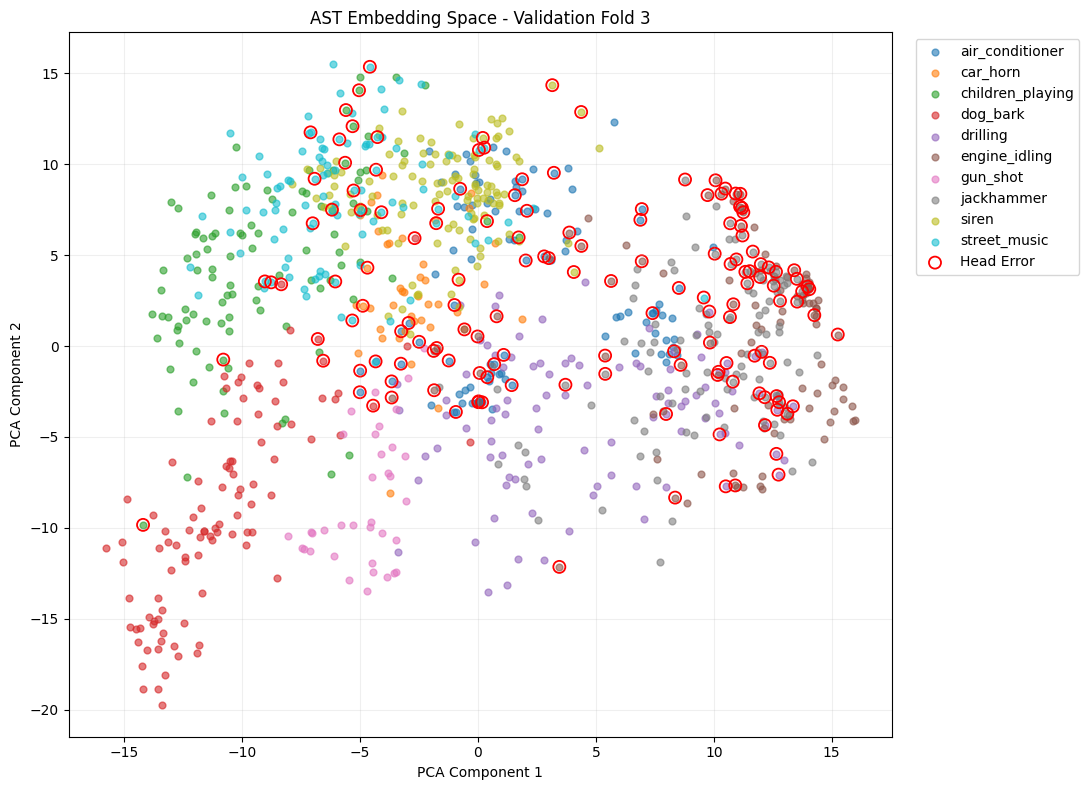

PCA Explained Variance: [0.0977 0.076 ]


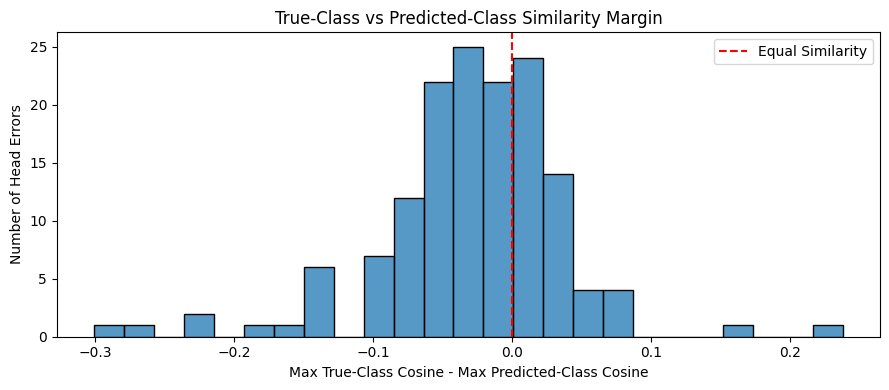


========== MANUAL AUDIO INSPECTION ==========

File: 93065-9-0-17.wav
True: street_music
AST Head: children_playing
KNN: children_playing
Confidence: 90.92 %
Similarity Margin: -0.0607


,Training File,Neighbor Class,Cosine Similarity
0,178520-2-0-29.wav,children_playing,0.8398
1,84359-2-0-1.wav,children_playing,0.8355
2,15564-2-0-1.wav,children_playing,0.8341
3,84359-2-0-2.wav,children_playing,0.8322
4,165529-2-0-8.wav,children_playing,0.8204



File: 17615-3-0-6.wav
True: dog_bark
AST Head: siren
KNN: siren
Confidence: 89.6 %
Similarity Margin: -0.1866


,Training File,Neighbor Class,Cosine Similarity
0,34952-8-0-4.wav,siren,0.8770
1,34952-8-0-3.wav,siren,0.8676
2,34952-8-0-5.wav,siren,0.8540
3,74726-8-2-0.wav,siren,0.8075
4,34952-8-0-2.wav,siren,0.8041



File: 62837-7-1-24.wav
True: jackhammer
AST Head: air_conditioner
KNN: air_conditioner
Confidence: 88.73 %
Similarity Margin: -0.0435


,Training File,Neighbor Class,Cosine Similarity
0,189987-0-0-4.wav,air_conditioner,0.8759
1,189991-0-0-7.wav,air_conditioner,0.8715
2,189987-0-0-3.wav,air_conditioner,0.8699
3,189987-0-0-1.wav,air_conditioner,0.8592
4,189987-0-0-0.wav,air_conditioner,0.8570



========== EXPERIMENT SUMMARY ==========
Validation Samples: 925
AST Head Accuracy: 0.84
KNN Accuracy: 0.8043
AST Head Macro-F1: 0.8554
KNN Macro-F1: 0.8185

Head Wrong / KNN Correct: 39
Both Wrong: 109

Interpretation:
Head wrong + KNN correct: possible decision-boundary issue
Both wrong: investigate representation overlap or ambiguity
These are diagnostic hypotheses, not causal proof.

Experiment completed successfully!
Trained model weights unchanged.
Test Fold 10 untouched.
No files saved.


========== EXPERIMENT CONFIGURATION ==========
Source fsID: 62837
Validation Fold: 3
Embedding Dimension: 768
Number of Paired Comparisons: 3
Model Training: DISABLED
Test Fold: NOT USED

========== MOST PROBLEMATIC SOURCES ==========


,fsID,class,Samples,Correct,Errors,Error_Rate
38,62837,jackhammer,66,44,22,0.3333
39,63095,drilling,22,6,16,0.7273
8,17853,engine_idling,16,3,13,0.8125
110,177742,air_conditioner,24,15,9,0.3750
84,146714,air_conditioner,24,16,8,0.3333
82,144068,engine_idling,34,28,6,0.1765
99,165039,jackhammer,29,25,4,0.1379
61,98681,street_music,6,2,4,0.6667
56,93065,street_music,6,2,4,0.6667
0,6988,engine_idling,6,3,3,0.5000



========== SELECTED SOURCE ==========
fsID: 62837
True Class: jackhammer
Most Confused With: air_conditioner
Total Clips: 66
Correct Clips: 44
Incorrect Clips: 22
Error Rate: 0.3333

Salience Distribution:
salience
1    66
Name: count, dtype: int64

========== EXTRACTING ACOUSTIC FEATURES ==========


Analyzing source clips:   0%|          | 0/66 [00:00<?, ?it/s]

Acoustic feature extraction completed!

========== ACOUSTIC FEATURE COMPARISON ==========


,Feature,Correct_Median,Wrong_Median,Wrong_minus_Correct
0,RMS_dB,-22.3002,-21.7424,0.5578
1,Energy_CV,0.1391,0.1249,-0.0142
2,Centroid_Hz,1828.5942,1712.3954,-116.1988
3,Flatness,0.0397,0.0325,-0.0072
4,HighFreq_Ratio,0.0744,0.0524,-0.0220
5,ZCR,0.1297,0.1162,-0.0134
6,Duration_s,4.0000,4.0000,0.0000


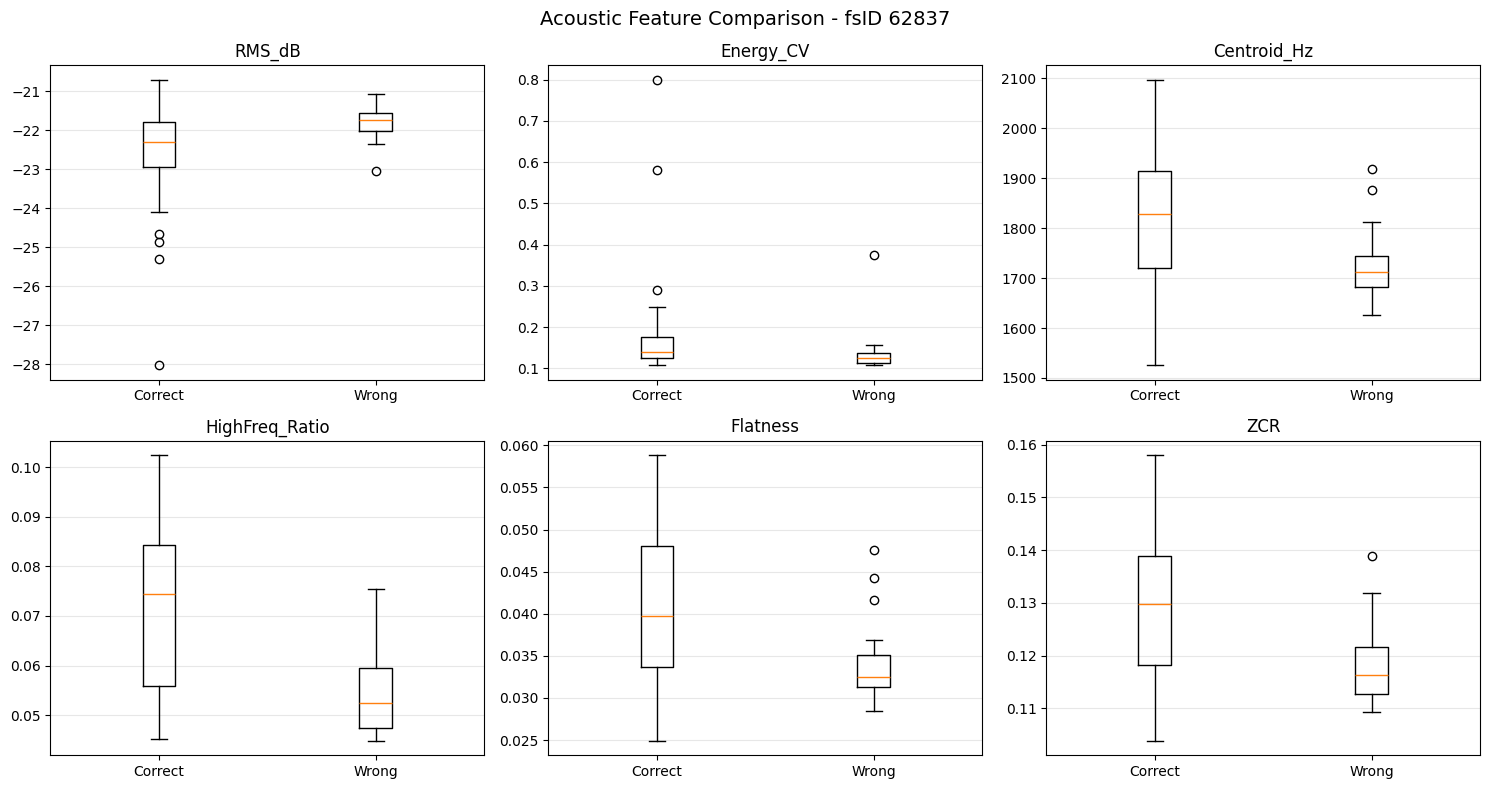


========== EMBEDDING COMPARISON ==========


,Metric,Correct_Median,Wrong_Median,Difference
0,Sim_True_Class,0.7629,0.7732,0.0103
1,Sim_Confused_Class,0.7486,0.8363,0.0877
2,Cosine_Margin,0.0154,-0.0502,-0.0656
3,P_True_Class,0.6599,0.2486,-0.4113
4,P_Confused_Class,0.1129,0.5633,0.4503


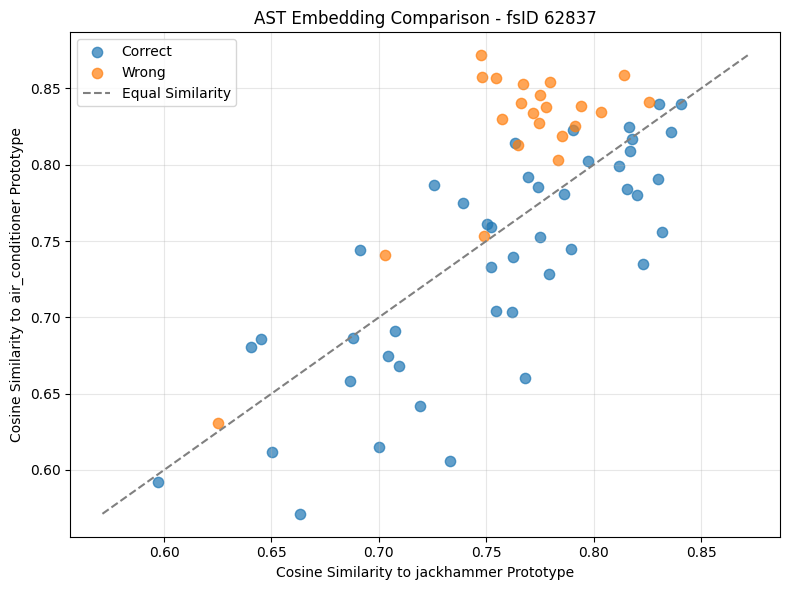


========== REPRESENTATION DIAGNOSTIC ==========
Wrong clips closer to confused-class prototype: 22 / 22
Head errors where KNN is also wrong: 20


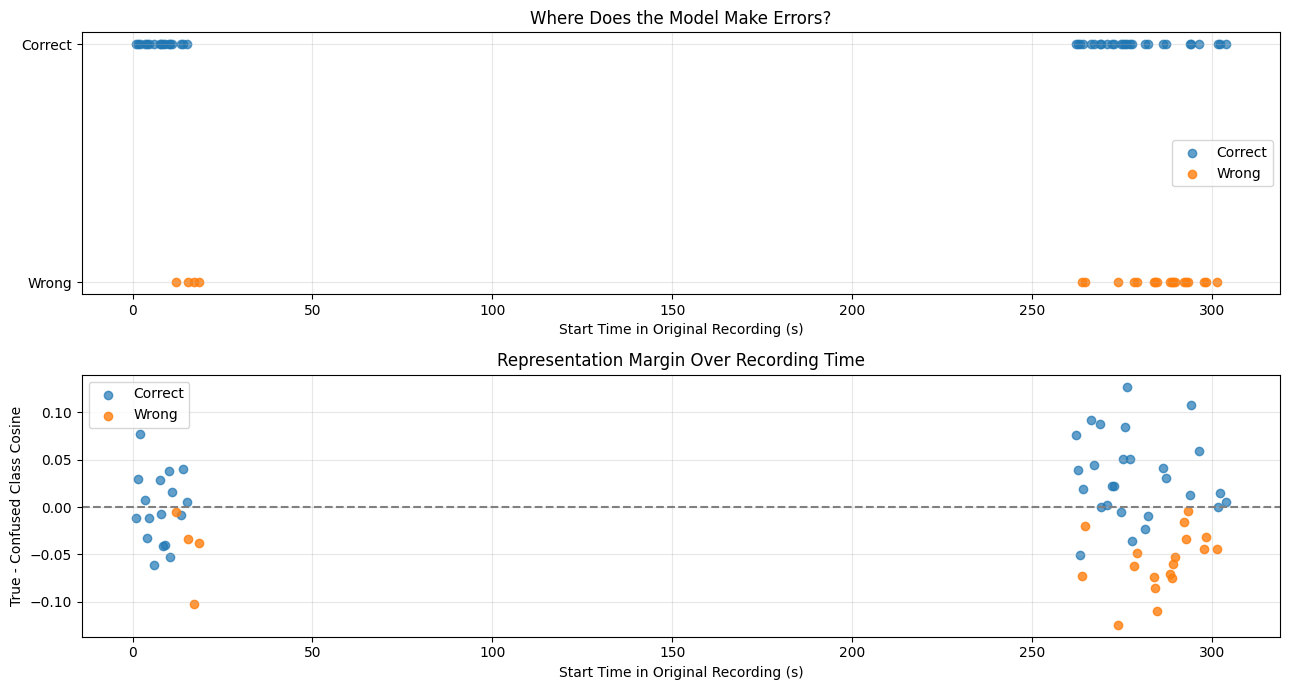


========== SELECTED PAIRS ==========


,Correct_File,Wrong_File,Wrong_Prediction,Time_Gap_s,Embedding_Cosine
0,62837-7-1-22.wav,62837-7-1-24.wav,air_conditioner,1.0,0.797
1,62837-7-0-30.wav,62837-7-0-34.wav,air_conditioner,2.0,0.858
2,62837-7-1-51.wav,62837-7-1-53.wav,air_conditioner,1.0,0.892


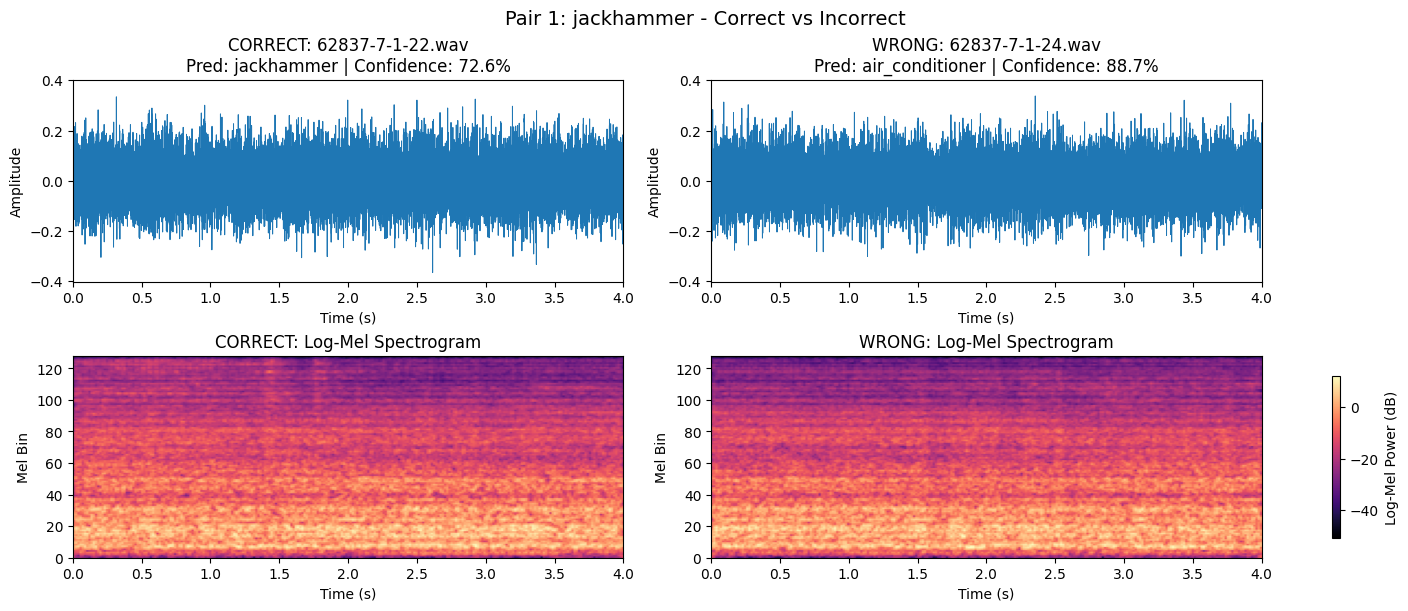


========== PAIR 1 FEATURES ==========


,slice_file_name,start,head_correct,head_pred_class,RMS_dB,Energy_CV,Centroid_Hz,Flatness,HighFreq_Ratio,Sim_True_Class,Sim_Confused_Class,Cosine_Margin
725,62837-7-1-22.wav,272.7067,True,jackhammer,-21.8385,0.1137,1805.6583,0.0423,0.0780,0.7624,0.7398,0.0226
726,62837-7-1-24.wav,273.7067,False,air_conditioner,-22.0837,0.1213,1671.3230,0.0310,0.0694,0.7474,0.8717,-0.1243



Correct Audio:


Incorrect Audio:


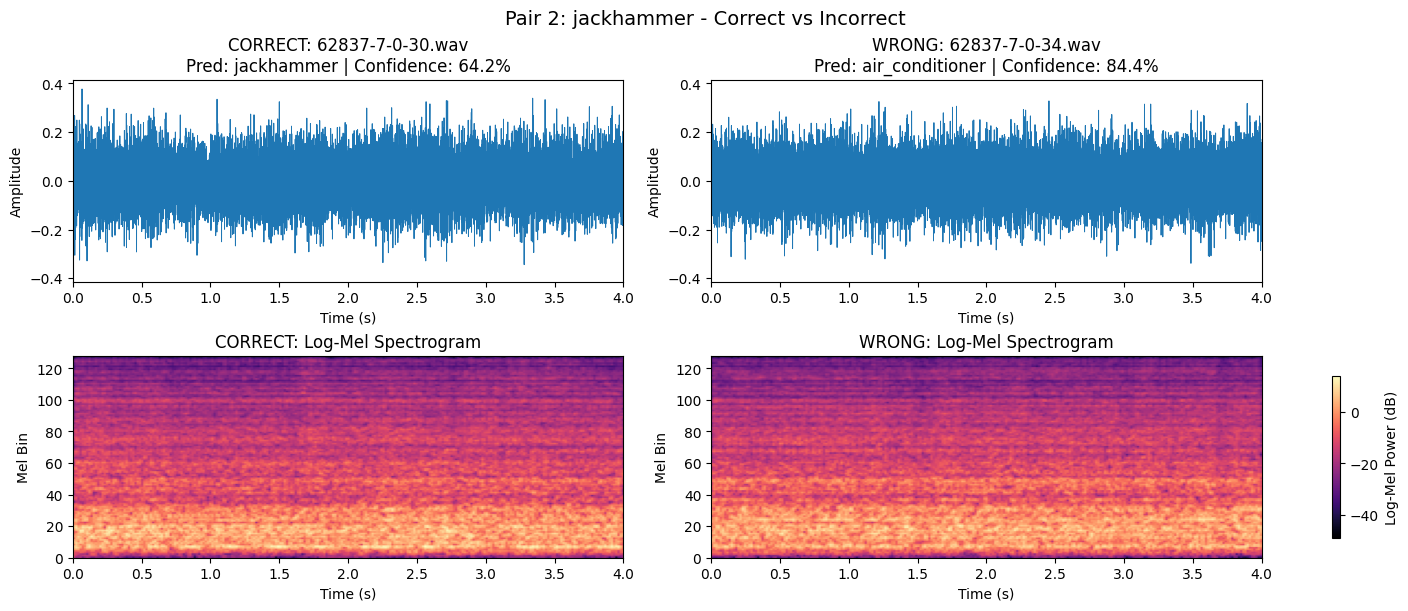


========== PAIR 2 FEATURES ==========


,slice_file_name,start,head_correct,head_pred_class,RMS_dB,Energy_CV,Centroid_Hz,Flatness,HighFreq_Ratio,Sim_True_Class,Sim_Confused_Class,Cosine_Margin
710,62837-7-0-30.wav,15.0,True,jackhammer,-21.2761,0.1247,1751.0444,0.0357,0.0602,0.7862,0.7811,0.0052
712,62837-7-0-34.wav,17.0,False,air_conditioner,-21.6177,0.1067,1752.8132,0.0369,0.0653,0.7545,0.8570,-0.1024



Correct Audio:


Incorrect Audio:


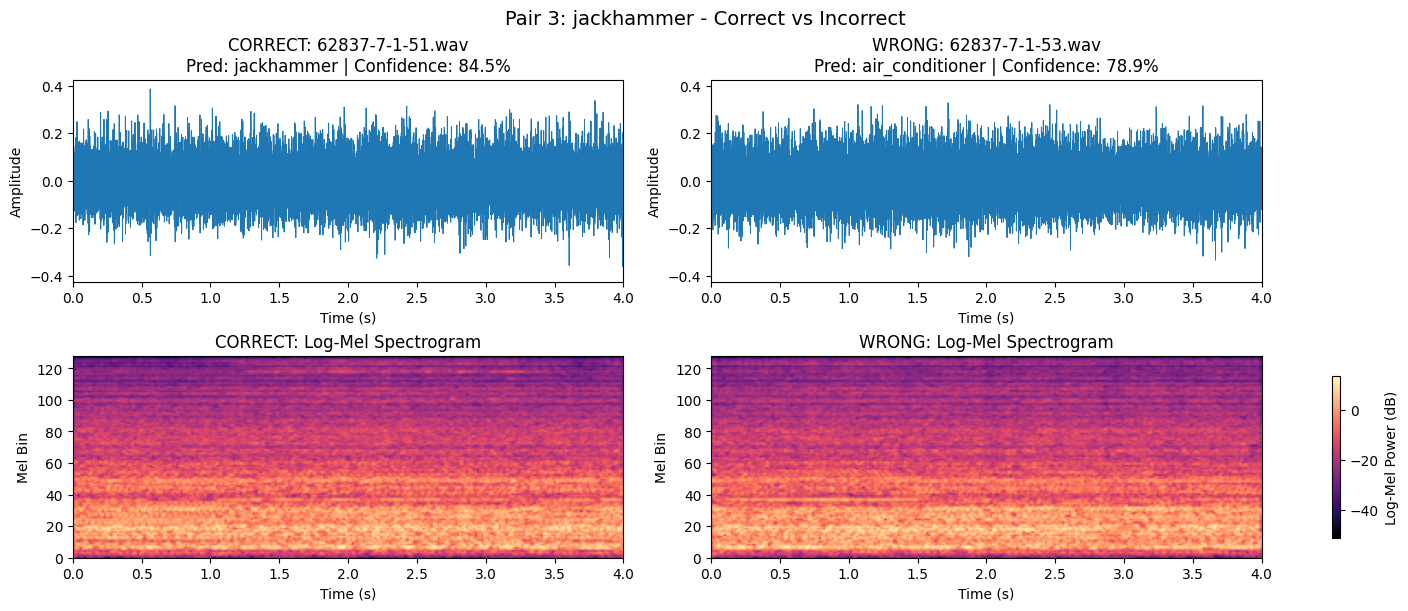


========== PAIR 3 FEATURES ==========


,slice_file_name,start,head_correct,head_pred_class,RMS_dB,Energy_CV,Centroid_Hz,Flatness,HighFreq_Ratio,Sim_True_Class,Sim_Confused_Class,Cosine_Margin
744,62837-7-1-51.wav,287.2067,True,jackhammer,-21.7205,0.1103,1732.3542,0.0345,0.0539,0.8154,0.7843,0.0311
745,62837-7-1-53.wav,288.2067,False,air_conditioner,-21.5425,0.1081,1704.9445,0.0325,0.0472,0.7751,0.8457,-0.0706



Correct Audio:


Incorrect Audio:



========== FINAL DIAGNOSTIC SUMMARY ==========
Source: 62837
Class: jackhammer
Primary Confusion: air_conditioner

Correct Samples: 44
Wrong Samples: 22

Median RMS Energy:
Correct: -22.3002
Wrong: -21.7424

Median Energy Variation:
Correct: 0.1391
Wrong: 0.1249

Median Spectral Centroid:
Correct: 1828.59
Wrong: 1712.4

Median Embedding Margin:
Correct: 0.0154
Wrong: -0.0502

IMPORTANT:
These differences are descriptive associations.
They do not establish a causal explanation.
Clips from the same recording may overlap.

Experiment 2 completed successfully!
No model training performed.
Test Fold 10 untouched.
No output files created.


========== EXPERIMENT CONFIGURATION ==========
Device: cuda:0
Source fsID: 62837
True Class: jackhammer
Confused Class: air_conditioner
Total Source Clips: 66
Correct Clips: 44
Wrong -> Air Conditioner: 21
Other Errors Excluded: 1
Time Bands: 8
Frequency Bands: 8
Test Fold: NOT USED

Training-only class prototypes prepared.

========== SOURCE-WIDE OCCLUSION ==========


Analyzing Source Clips:   0%|          | 0/65 [00:00<?, ?it/s]


Occlusion evaluation completed!
Total Perturbation Evaluations: 1040

========== TIME/FREQUENCY SUMMARY ==========


,mask_type,band,group,Mean_Delta,Median_Delta,Mean_Embedding_Delta,Correct_After_Mask,Samples
0,Frequency,0,Correct,-0.6565,-0.6934,-0.0045,33,44
1,Frequency,0,Wrong,-0.6472,-0.5928,-0.0074,0,21
2,Frequency,1,Correct,-0.0701,-0.0115,-0.0032,39,44
3,Frequency,1,Wrong,0.2003,0.2085,0.0065,3,21
4,Frequency,2,Correct,-0.0980,-0.1696,-0.0083,41,44
5,Frequency,2,Wrong,-0.0055,-0.0283,-0.0098,1,21
6,Frequency,3,Correct,0.0050,-0.0347,-0.0050,40,44
7,Frequency,3,Wrong,0.1026,0.1875,-0.0044,2,21
8,Frequency,4,Correct,-0.2643,-0.2864,-0.0145,38,44
9,Frequency,4,Wrong,-0.2938,-0.3086,-0.0129,0,21


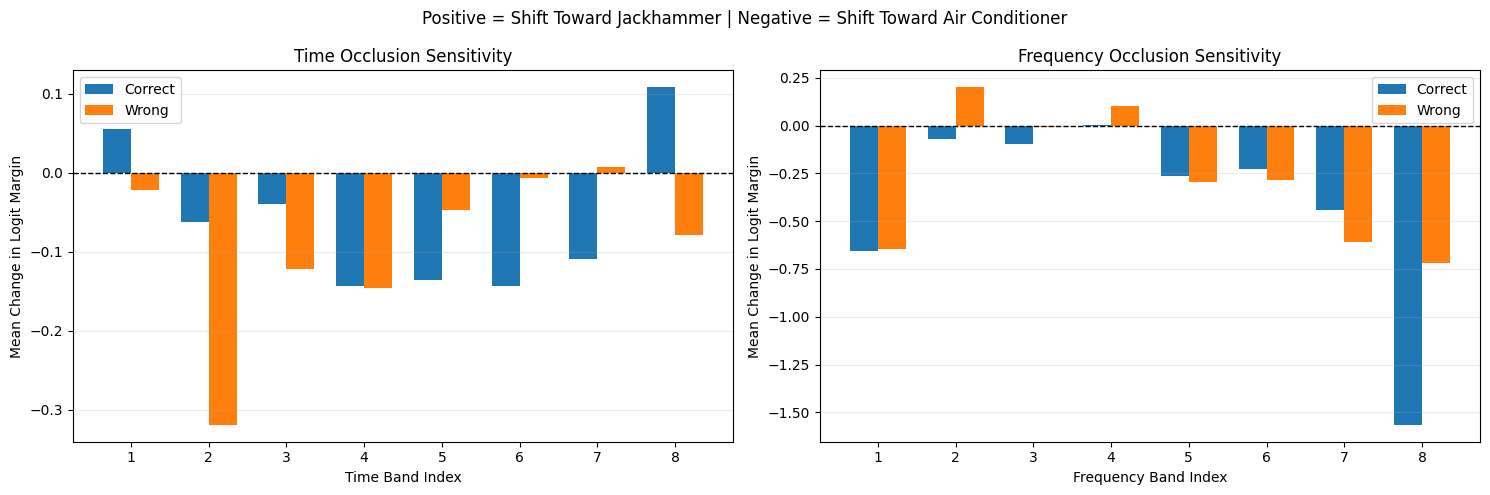


========== MOST INFLUENTIAL REGIONS ==========

Wrong clips: masking regions that MOST increase jackhammer margin


,filename,mask_type,band,delta_margin,delta_cosine_margin,masked_pred
969,62837-7-1-79.wav,Frequency,1,1.0645,0.0215,7
247,62837-7-0-37.wav,Time,7,0.8594,0.0066,7
452,62837-7-1-24.wav,Time,4,0.8145,0.0197,0
458,62837-7-1-24.wav,Frequency,2,0.7227,0.0003,0
249,62837-7-0-37.wav,Frequency,1,0.7031,0.0069,0
587,62837-7-1-33.wav,Frequency,3,0.6445,0.0011,7
581,62837-7-1-33.wav,Time,5,0.6270,0.0214,7
250,62837-7-0-37.wav,Frequency,2,0.5820,0.0034,0
758,62837-7-1-53.wav,Time,6,0.5410,0.0130,0
869,62837-7-1-63.wav,Time,5,0.4971,-0.0047,7



Correct clips: masking regions that MOST decrease jackhammer margin


,filename,mask_type,band,delta_margin,delta_cosine_margin,masked_pred
31,62837-7-0-15.wav,Frequency,7,-4.2854,-0.1403,0
175,62837-7-0-28.wav,Frequency,7,-3.8320,-0.1157,0
47,62837-7-0-16.wav,Frequency,7,-3.5625,-0.1111,0
495,62837-7-1-27.wav,Frequency,7,-3.2869,-0.1256,7
447,62837-7-1-22.wav,Frequency,7,-2.9141,-0.1015,0
479,62837-7-1-26.wav,Frequency,7,-2.8604,-0.0902,0
559,62837-7-1-31.wav,Frequency,7,-2.7288,-0.1042,0
111,62837-7-0-20.wav,Frequency,7,-2.7212,-0.1026,4
431,62837-7-1-21.wav,Frequency,7,-2.6445,-0.0915,0
207,62837-7-0-30.wav,Frequency,7,-2.5830,-0.0702,0



========== SELECTED PAIRS ==========


,Correct File,Wrong File,Time Gap (s),Wrong Confidence
0,62837-7-1-22.wav,62837-7-1-24.wav,1.0,0.8873
1,62837-7-0-30.wav,62837-7-0-34.wav,2.0,0.8437
2,62837-7-1-51.wav,62837-7-1-53.wav,1.0,0.7891



========== LOCAL OCCLUSION MAPS ==========


Computing 2D Occlusion:   0%|          | 0/6 [00:00<?, ?it/s]

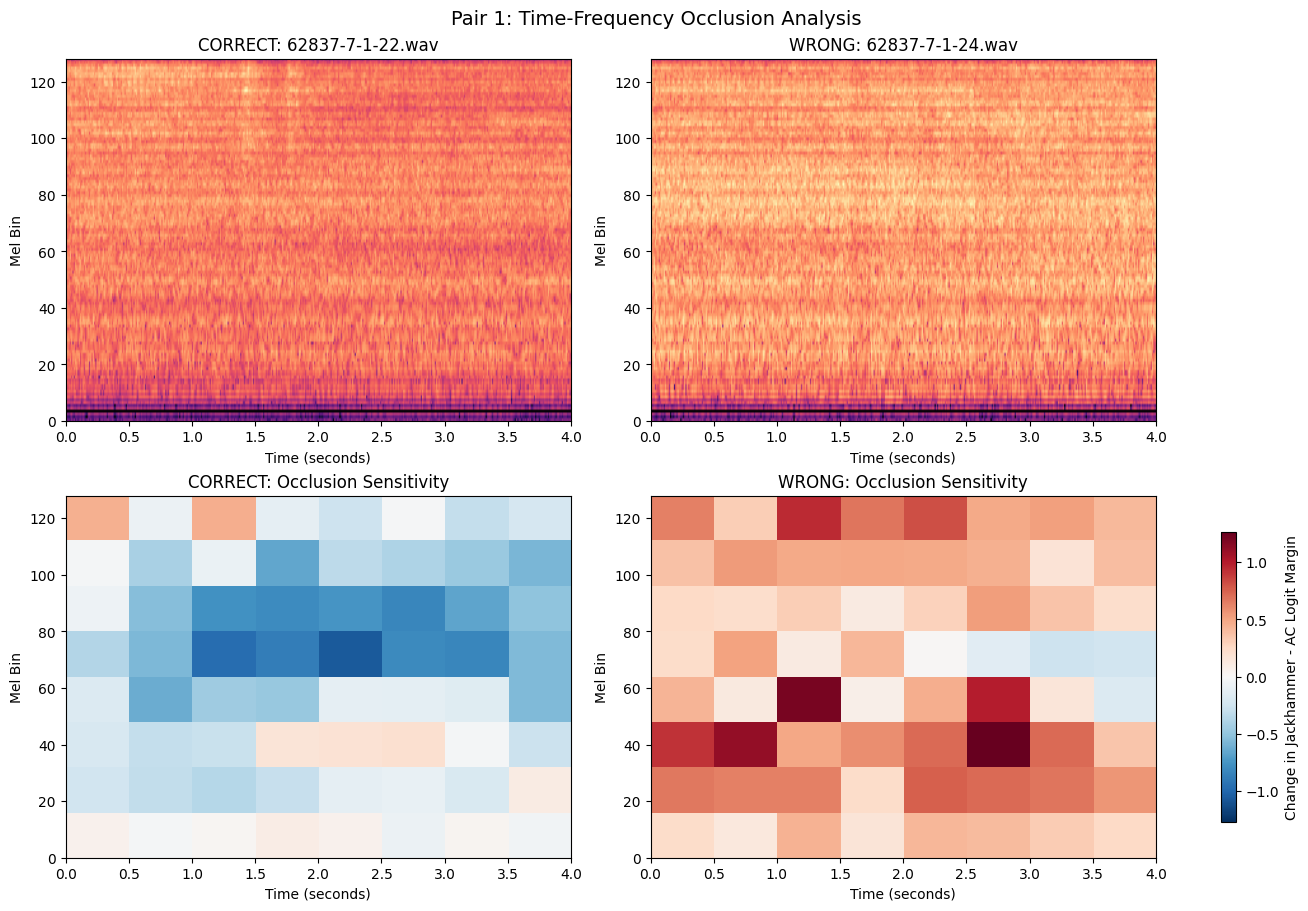


Pair 1 Findings:
Wrong clip strongest positive response: Time Band 6, Frequency Band 3, Delta=1.2642
Correct clip strongest negative response: Time Band 5, Frequency Band 5, Delta=-1.0645


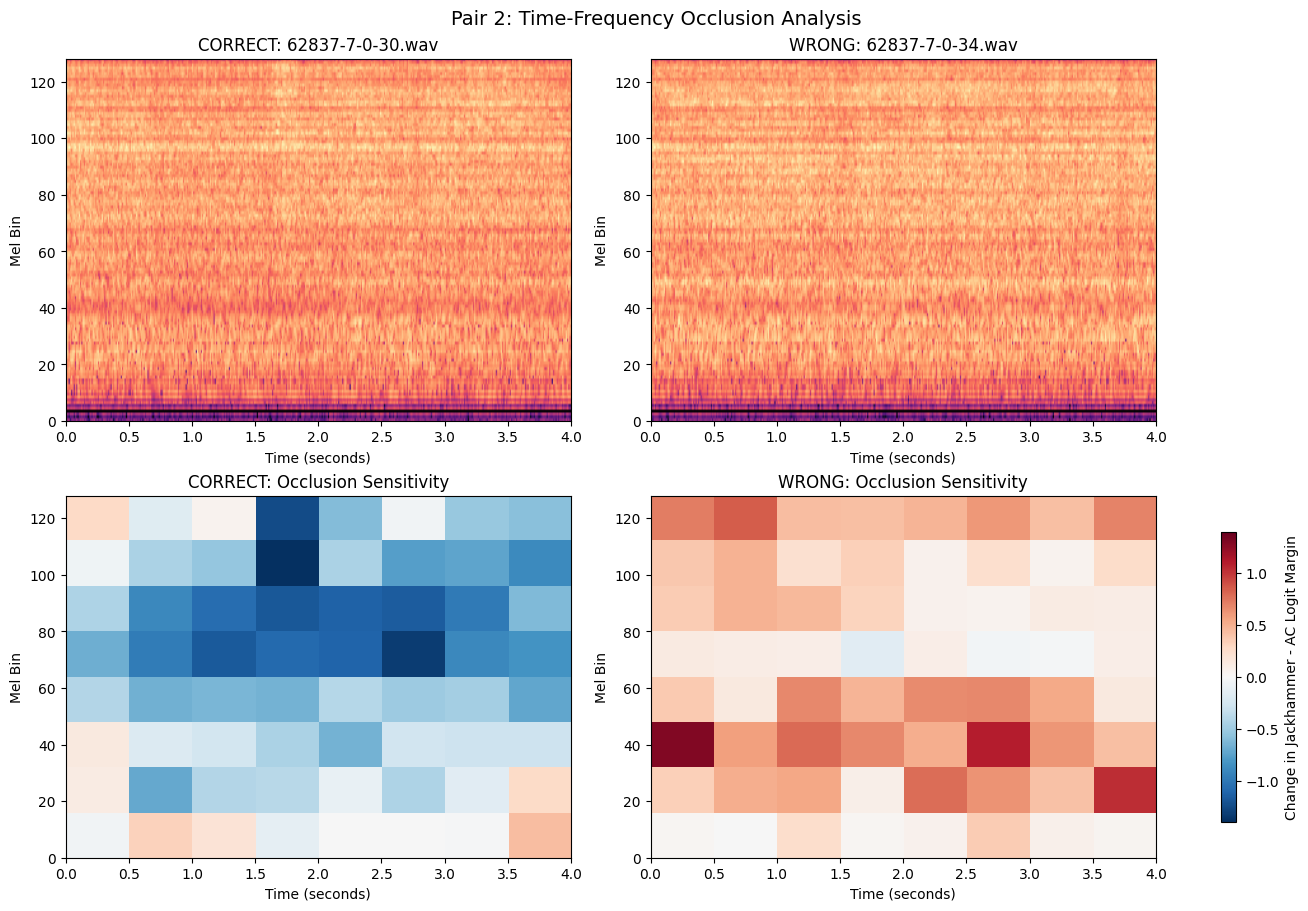


Pair 2 Findings:
Wrong clip strongest positive response: Time Band 1, Frequency Band 3, Delta=1.2930
Correct clip strongest negative response: Time Band 4, Frequency Band 7, Delta=-1.3936


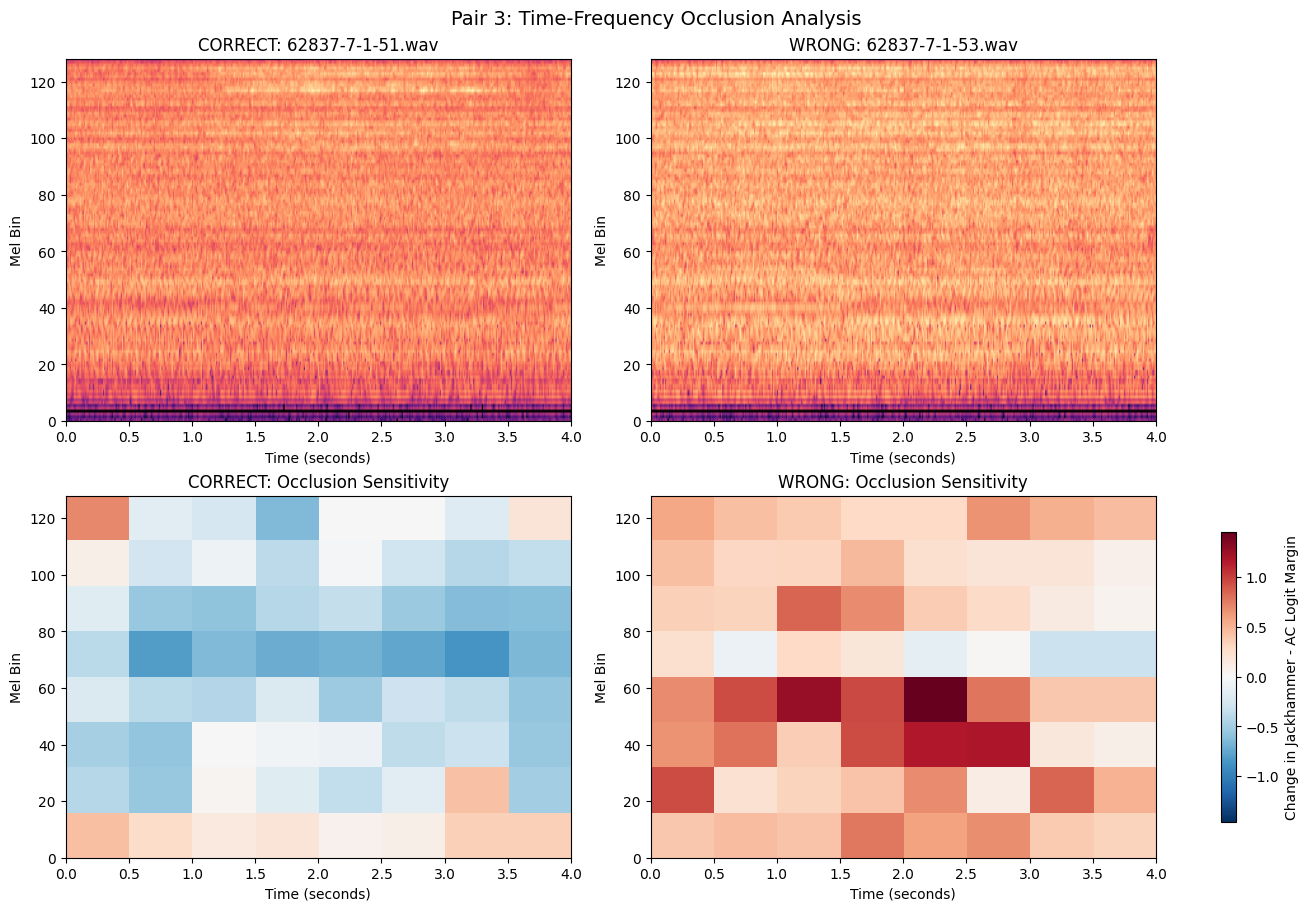


Pair 3 Findings:
Wrong clip strongest positive response: Time Band 5, Frequency Band 4, Delta=1.4541
Correct clip strongest negative response: Time Band 7, Frequency Band 5, Delta=-0.8545

========== FILL VALUE CONTROL ==========


,File,Fill,Time_Band,Freq_Band,Delta_Margin
0,62837-7-1-24.wav,Zero,6,3,1.2651
1,62837-7-1-24.wav,Sample_Mean,6,3,0.2549
2,62837-7-0-34.wav,Zero,1,3,1.2930
3,62837-7-0-34.wav,Sample_Mean,1,3,0.7749
4,62837-7-1-53.wav,Zero,5,4,1.4531
5,62837-7-1-53.wav,Sample_Mean,5,4,0.2783



========== PREDICTION FLIP ANALYSIS ==========
Wrong -> Correct after 1D masking: 14 perturbations
Correct -> Wrong after 1D masking: 86 perturbations

Unique wrong samples corrected by some mask: 6

Top masks that corrected wrong predictions:


,filename,mask_type,band,delta_margin,delta_cosine_margin
969,62837-7-1-79.wav,Frequency,1,1.0645,0.0215
247,62837-7-0-37.wav,Time,7,0.8594,0.0066
587,62837-7-1-33.wav,Frequency,3,0.6445,0.0011
581,62837-7-1-33.wav,Time,5,0.6270,0.0214
869,62837-7-1-63.wav,Time,5,0.4971,-0.0047
841,62837-7-1-61.wav,Frequency,1,0.4170,0.0207
838,62837-7-1-61.wav,Time,6,0.4082,0.0016
826,62837-7-1-6.wav,Frequency,2,0.3750,0.0050
864,62837-7-1-63.wav,Time,0,0.3135,0.0061
816,62837-7-1-6.wav,Time,0,0.2930,0.0032



========== FINAL EXPERIMENT SUMMARY ==========
Source: 62837
True Class: jackhammer
Confused Class: air_conditioner

Source Clips Analyzed: 65
1D Perturbations: 1040
2D Perturbations: 384

Interpretation:
Positive delta = masking shifts relative evidence toward jackhammer.
Negative delta = masking shifts relative evidence toward air_conditioner.
Effects may depend on mask size and fill value.
Occlusion sensitivity does not establish acoustic causality.

Model weights unchanged.
No training performed.
Test Fold 10 untouched.
No files saved.

EXPERIMENT 3 COMPLETED!


[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `527`.


========== CONFIGURATION ==========
Mode: development
GPU: Tesla T4
Seeds: (42,)
Audio Policy: tile
Mixup Alpha: 0.0
Trainable Blocks: [8, 9, 10, 11]
Epochs: 12
Effective Batch Size: 32
Evaluation Views: 3
Total Dataset Samples: 8732

DEVELOPMENT: VALIDATION FOLD 3

========== DATA SPLIT ==========
Train: 6970
Inner Validation: 925
Evaluation: 925
Source separation: PASSED


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

[transformers] ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                          
------------------------+----------+------------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([10])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.



========== MODEL ==========
Trainable Parameters: 28,362,250
Layer-wise Learning Rates:
  Block 8: 0.00000844
  Block 9: 0.00001125
  Block 10: 0.00001500
  Block 11: 0.00002000
  Classification Head: 0.001

========== TRAINING STARTED ==========
Seed: 42


...

Source Bootstrap:   0%|          | 0/500 [00:00<?, ?it/s]


========== FINAL RESULTS ==========
Mode: development
Seeds: (42,)
Inference Views: 3

Accuracy: 0.7914
95% Source-Bootstrap CI: [0.6909, 0.8862]

Macro-F1: 0.8028
95% Source-Bootstrap CI: [0.7231, 0.8699]

========== OLD vs NEW ==========
Old Validation Accuracy: 0.8400
New Validation Accuracy: 0.7914
Accuracy Change: -0.0486

Old Validation Macro-F1: 0.8554
New Validation Macro-F1: 0.8028
Macro-F1 Change: -0.0526

========== TRAINING HISTORY ==========


,seed,epoch,train_loss,val_accuracy,val_macro_f1,outer_fold
0,42,1,1.0237,0.7903,0.7983,3
1,42,2,0.6347,0.7903,0.8014,3
2,42,3,0.5902,0.7816,0.7933,3
3,42,4,0.5663,0.7459,0.7575,3
4,42,5,0.5543,0.7589,0.7665,3



========== PER-CLASS PERFORMANCE ==========


,precision,recall,f1-score,support
air_conditioner,0.7258,0.4500,0.5556,100.0
car_horn,0.7963,1.0000,0.8866,43.0
children_playing,0.8750,0.9100,0.8922,100.0
dog_bark,0.8899,0.9700,0.9282,100.0
drilling,0.6667,0.9600,0.7869,100.0
engine_idling,0.6333,0.5327,0.5787,107.0
gun_shot,0.9730,1.0000,0.9863,36.0
jackhammer,0.6518,0.6083,0.6293,120.0
siren,0.9912,0.9496,0.9700,119.0
street_music,0.8182,0.8100,0.8141,100.0


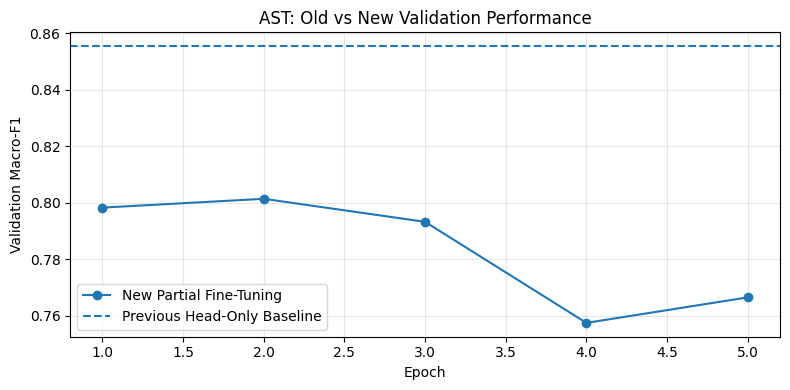


========== EXPERIMENT COMPLETED ==========
Total Time: 34.00 minutes
Previous head-only model: NOT MODIFIED
Output files created: NONE
Fold 10: NOT EVALUATED
Trained development models retained in trained_models_new (CPU RAM).

IMPROVED AST PIPELINE FINISHED!


In [ ]:
sdasadassda sd